**Experiment A**

In [1]:
# Cell 1 — Install
# Keep Colab's own torch/torchvision pair: install opacus WITHOUT dependencies so pip cannot replace torch.
# (Installing an unpinned torchvision on the current Colab image breaks `import torchvision`.)
!pip -q install --no-deps opacus==1.4.0
import torch, torchvision, opacus
print('torch', torch.__version__, '| torchvision', torchvision.__version__, '| opacus', opacus.__version__, '| cuda', torch.cuda.is_available())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 6.8 MB/s eta 0:00:00
torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | opacus 1.4.0 | cuda True


In [2]:
# Cell 2 — Imports + reproducibility
import os, math, random
from copy import deepcopy

import numpy as np
import pandas as pd
from tqdm import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt


# Wider alpha grid => avoids "optimal order is the largest alpha" warning
RDP_ALPHAS = (
    [1.01, 1.05] +
    [1.1 + 0.1*i for i in range(0, 90)] +      # 1.1..10.0
    list(range(11, 64)) + [64, 128, 256, 512]
)

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def cleanup_cuda():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [3]:
# Cell 3 — Dataset: Fashion-MNIST + loaders
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.2860,), (0.3530,))
])

train_ds = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

test_loader = DataLoader(
    test_ds,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("train:", len(train_ds), "test:", len(test_ds))

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 199kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.0MB/s]


train: 60000 test: 10000


In [4]:
# Cell 4 — PUBLIC set + IID clients
# Public points removed from private client datasets.

NUM_CLASSES = 10
PUBLIC_PER_CLASS = 20
SAMPLES_PER_CLIENT = 10
CLIENTS_PER_ROUND = 100

def extract_public_per_class(dataset, per_class=20, seed=0):
    rng = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    public_idx = []
    for k in range(NUM_CLASSES):
        cls_idx = np.where(targets == k)[0]
        rng.shuffle(cls_idx)
        public_idx.extend(cls_idx[:per_class].tolist())
    return sorted(public_idx)

public_idx = extract_public_per_class(train_ds, per_class=PUBLIC_PER_CLASS, seed=0)

all_train_idx = np.arange(len(train_ds))
mask = np.ones(len(train_ds), dtype=bool)
mask[np.array(public_idx)] = False
avail_idx = all_train_idx[mask]  # private-only indices

NUM_CLIENTS = len(avail_idx) // SAMPLES_PER_CLIENT
private_needed = NUM_CLIENTS * SAMPLES_PER_CLIENT
avail_idx = avail_idx[:private_needed]

def build_iid_clients_from_indices(indices, num_clients, samples_per_client, seed=0):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(indices)
    return [
        perm[i*samples_per_client:(i+1)*samples_per_client].tolist()
        for i in range(num_clients)
    ]

clients = build_iid_clients_from_indices(
    avail_idx, NUM_CLIENTS, SAMPLES_PER_CLIENT, seed=0
)

print("public samples:", len(public_idx), f"(per_class={PUBLIC_PER_CLASS})")
print("private samples:", len(avail_idx))
print("NUM_CLIENTS:", NUM_CLIENTS, "| samples/client:", SAMPLES_PER_CLIENT, "| clients/round:", CLIENTS_PER_ROUND)
print("q =", CLIENTS_PER_ROUND / NUM_CLIENTS)

public samples: 200 (per_class=20)
private samples: 59800
NUM_CLIENTS: 5980 | samples/client: 10 | clients/round: 100
q = 0.016722408026755852


/tmp/ipykernel_3430/2050036623.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  targets = np.array(dataset.targets)


In [5]:
# Cell 4b — OPTIONAL speed-up : cache the datasets as tensors once.
# client_update() builds a new DataLoader per client per round and re-applies ToTensor/Normalize to
# every image on every access; with 100 clients x 180 rounds that CPU work, not the GPU, dominates the
# run time.  Caching applies the same transforms exactly once, so every sample tensor is identical and
# the training numbers are unchanged; runs are typically 1.5-2x faster.  Set to False to disable.
USE_CACHED_TENSORS = True
if USE_CACHED_TENSORS:
    from torch.utils.data import TensorDataset
    class _CachedDS(TensorDataset):
        def __init__(self, ds):
            xs, ys = [], []
            for x, y in DataLoader(ds, batch_size=1024, shuffle=False, num_workers=0):
                xs.append(x); ys.append(y)
            X, Y = torch.cat(xs), torch.cat(ys)
            super().__init__(X, Y)
            self.targets = Y.tolist()
    train_ds = _CachedDS(train_ds)
    test_ds = _CachedDS(test_ds)
    test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)
    print("cached tensors -> train:", tuple(train_ds.tensors[0].shape), "test:", tuple(test_ds.tensors[0].shape))


cached tensors -> train: (60000, 1, 28, 28) test: (10000, 1, 28, 28)


In [6]:
# Cell 4c — Cohort sampling: POISSON 
# Each client participates in a round independently with probability q = CLIENTS_PER_ROUND / N, so the cohort
# has expected size CLIENTS_PER_ROUND and random realized size. This is the sampler the subsampled-Gaussian
# accountant (Poisson subsampling, add/remove adjacency) assumes; fixed-size sampling is not (Lebeda et al., SaTML 2025).
# Denominators that enter a sensitivity bound stay PUBLIC: the private means divide by the expected size
# CLIENTS_PER_ROUND, and AG-PTR caps its noisy count at the public constant COUNT_CAP.
SAMPLING = "poisson"
COUNT_CAP = 2 * CLIENTS_PER_ROUND

def sample_cohort(rng, num_clients, expected):
    if SAMPLING == "poisson":
        chosen = np.flatnonzero(rng.rand(num_clients) < (float(expected) / float(num_clients)))
        if len(chosen) == 0:                       # probability (1-q)^N ~ e^-100; keep the round well defined
            chosen = rng.choice(num_clients, size=1, replace=False)
        return chosen
    return rng.choice(num_clients, size=expected, replace=False)
print("SAMPLING =", SAMPLING, "| expected cohort", CLIENTS_PER_ROUND, "| count cap", COUNT_CAP)


SAMPLING = poisson | expected cohort 100 | count cap 200


In [7]:
# Cell 6 — Model + evaluation
class FMNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)  # 14x14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)  # 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

In [8]:
# Cell 7 — Tensor-list + flatten helpers
def model_param_list(model):
    return [p for p in model.parameters() if p.requires_grad]

@torch.no_grad()
def zero_like_params(model):
    return [torch.zeros_like(p.data) for p in model_param_list(model)]

@torch.no_grad()
def add_update_(model, update_list, scale=1.0):
    for p, u in zip(model_param_list(model), update_list):
        p.data.add_(u, alpha=scale)

@torch.no_grad()
def add_scaled_list_(dst, src, alpha):
    for d, s in zip(dst, src):
        d.add_(s, alpha=float(alpha))

@torch.no_grad()
def norm_sq_list(tlist):
    s = None
    for t in tlist:
        v = (t * t).sum()
        s = v if s is None else s + v
    return s + 1e-12

@torch.no_grad()
def l2_norm_list(tlist):
    return torch.sqrt(norm_sq_list(tlist))

def sub_list(a, b):
    return [x - y for x, y in zip(a, b)]

@torch.no_grad()
def dot_list(a_list, b_list):
    s = None
    for a, b in zip(a_list, b_list):
        v = (a * b).sum()
        s = v if s is None else s + v
    return s

@torch.no_grad()
def flatten_list(tlist):
    return torch.cat([t.reshape(-1) for t in tlist])

@torch.no_grad()
def unflatten_like(vec, template_list):
    out = []
    idx = 0
    for t in template_list:
        n = t.numel()
        out.append(vec[idx:idx+n].view_as(t))
        idx += n
    return out

In [9]:
# Cell 8 — Local client update
# Local client update (SGD) returns delta = (local - global)
# LF is interpreted as label flipping with cyclic shift y -> (y + 1) % NUM_CLASSES.

loss_fn = nn.CrossEntropyLoss()

def maybe_flip_labels(y, shift=1):
    return (y + int(shift)) % NUM_CLASSES

def client_update(global_model, client_indices, lr, momentum,
                  local_epochs=1, batch_size=10,
                  label_flip=False, label_flip_shift=1):
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, client_indices),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(local_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if label_flip:
                y = maybe_flip_labels(y, shift=label_flip_shift)

            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta.append((lp.data - gp.data).detach())

    del local_model
    return delta

In [10]:
# Cell 9 — DP accounting (RDP) + sigma search
# Purpose: compute epsilon for given noise multiplier(s) and binary-search sigma.


from opacus.accountants.analysis import rdp as rdp_analysis

def _compute_rdp(q, noise_multiplier, steps, orders):
    try:
        return rdp_analysis.compute_rdp(
            q=q, noise_multiplier=noise_multiplier, steps=steps, orders=orders
        )
    except TypeError:
        return rdp_analysis.compute_rdp(q, noise_multiplier, steps, orders)

def _get_eps(orders, rdp, delta):
    try:
        eps, _ = rdp_analysis.get_privacy_spent(
            orders=orders, rdp=rdp, delta=delta
        )
    except TypeError:
        eps, _ = rdp_analysis.get_privacy_spent(orders, rdp, delta)
    return float(eps)

def epsilon_from_sigma_single(sigma, q, steps, delta):
    rdp = _compute_rdp(q, float(sigma), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp, delta)


def find_sigma_for_target_eps_single(target_eps, q, steps, delta, iters=50):
    lo, hi = 1e-4, 1.0
    while epsilon_from_sigma_single(hi, q, steps, delta) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound. Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if epsilon_from_sigma_single(mid, q, steps, delta) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)

# ----composed ("certified") accountant for AG-PTR ----
# The two Gaussian phases of one AG-PTR round query the SAME sampled cohort, so the valid
# accounting composes them first into one Gaussian mechanism with effective multiplier
#   sigma_eff = (sigma_sel^-2 + sigma_rel^-2)^-1/2        (= (2/sqrt5)*sigma_rel when sigma_sel = 2*sigma_rel)
# and amplifies THAT mechanism at rate q. This is the only accountant used for AG-PTR.

def sigma_eff_two(sig_sel, sig_rel):
    return float((float(sig_sel) ** -2 + float(sig_rel) ** -2) ** -0.5)

def epsilon_certified_two(sig_sel, sig_rel, q, steps, delta):
    return epsilon_from_sigma_single(sigma_eff_two(sig_sel, sig_rel), q, steps, delta)

def find_sigma_rel_certified_two(target_eps, q, steps, delta, sel_factor=2.0, iters=50):
    # smallest sigma_rel whose CERTIFIED epsilon meets the target (sigma_sel = sel_factor*sigma_rel);
    # for eps=2.0 this equals (sqrt(1+sel_factor^2)/sel_factor) * sigma_dp, i.e. 1.0871 on Fashion-MNIST
    lo, hi = 1e-4, 1.0
    def E(sig_rel):
        return epsilon_certified_two(sel_factor * sig_rel, sig_rel, q, steps, delta)
    while E(hi) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound (certified).")
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if E(mid) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)


In [11]:
# Cell 10 — Attack helpers
# Byzantine attack helpers for:
#   ALIE, SF, MinMax, MinSum, LF, FoE
#
# Notes:
# - LF is implemented as label flipping and handled inside the train_* functions.
# - SF here is a sign-flip style update attack.
# - FoE here is an inner-product-manipulation / negative-mean style attack.

def normalize_attack_name(name):
    return str(name).strip().lower().replace("-", "").replace("_", "").replace(" ", "")

def is_label_flip_attack(name):
    return normalize_attack_name(name) in {"lf", "labelflip", "labelflipping"}


# ----defense-aware "in-ball" attack against AG-PTR ----
# The attacker knows the broadcast public anchor a_pub and the radius rho (both public).
# It submits a vector that (i) votes for the public anchor, (ii) lies inside the clipping
# ball so it is never truncated, and (iii) pushes the anchored mean opposite to the honest
# offset direction.  Its per-client influence is therefore exactly the bound rho/m_hat of
# the paper's analysis: bounded, but never filtered.  AG-PTR only (needs a_pub and rho).

def is_inball_attack(name):
    return normalize_attack_name(name) in {"inball", "inballattack", "adaptive", "defenseaware"}

@torch.no_grad()
def _attack_vec_inball(X, anchor_vec, rho, scale=1.0):
    mu = X.mean(dim=0)
    off = mu - anchor_vec
    n = float(torch.norm(off).item())
    if n < 1e-12:
        u = -torch.sign(mu)
        u = u / (torch.norm(u) + 1e-12)
    else:
        u = -off / n
    lam = float(scale) * float(rho)
    # keep the vote on the anchor: ||a + lam*u|| >= lam  <=>  ||a||^2 + 2*lam*<a,u> >= 0
    dot = float((anchor_vec * u).sum().item())
    if dot < 0.0:
        lam_max = float((anchor_vec * anchor_vec).sum().item()) / (-2.0 * dot)
        lam = min(lam, 0.999 * lam_max)
    return anchor_vec + lam * u

@torch.no_grad()
def mean_update_list(update_list):
    if len(update_list) == 0:
        raise ValueError("No updates available.")
    P = len(update_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([u[j] for u in update_list], dim=0).mean(dim=0).detach())
    return out

@torch.no_grad()
def _pairwise_sq_dists(X):
    gram = X @ X.t()
    diag = torch.diag(gram).unsqueeze(1)
    D = diag + diag.t() - 2.0 * gram
    return D.clamp_min(0.0)

@torch.no_grad()
def _deviation_vec(X):
    mu = X.mean(dim=0)
    sd = X.std(dim=0, unbiased=False)

    dev = sd * torch.sign(mu)
    if torch.norm(dev) < 1e-12:
        dev = mu.clone()
    if torch.norm(dev) < 1e-12:
        dev = torch.ones_like(mu)

    dev = dev / (torch.norm(dev) + 1e-12)
    return mu, dev

def _search_lambda(valid_fn, hi_init=1.0, iters=40):
    lo, hi = 0.0, float(hi_init)

    while valid_fn(hi):
        lo = hi
        hi *= 2.0
        if hi > 1e6:
            break

    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if valid_fn(mid):
            lo = mid
        else:
            hi = mid

    return float(lo)

@torch.no_grad()
def _attack_vec_alie(X, z=2.0, direction=-1.0):
    mu = X.mean(dim=0)
    sd = X.std(dim=0, unbiased=False) + 1e-12
    return mu + float(direction) * float(z) * sd

@torch.no_grad()
def _attack_vec_sf(X, scale=5.0):
    mu = X.mean(dim=0)
    mean_abs = X.abs().mean(dim=0) + 1e-12
    return -float(scale) * torch.sign(mu) * mean_abs

@torch.no_grad()
def _attack_vec_foe(X, scale=1.0):
    mu = X.mean(dim=0)
    return -float(scale) * mu

@torch.no_grad()
def _attack_vec_minmax(X):
    mu, dev = _deviation_vec(X)
    D = _pairwise_sq_dists(X)
    thr = float(D.max().item())
    x_norm_sq = (X * X).sum(dim=1)

    def valid_fn(lam):
        c = mu - float(lam) * dev
        c_norm_sq = (c * c).sum()
        sq = x_norm_sq + c_norm_sq - 2.0 * (X @ c)
        return float(sq.max().item()) <= thr + 1e-8

    lam = _search_lambda(valid_fn)
    return mu - lam * dev

@torch.no_grad()
def _attack_vec_minsum(X):
    mu, dev = _deviation_vec(X)
    D = _pairwise_sq_dists(X)
    thr = float(D.sum(dim=1).max().item())
    x_norm_sq = (X * X).sum(dim=1)

    def valid_fn(lam):
        c = mu - float(lam) * dev
        c_norm_sq = (c * c).sum()
        sq = x_norm_sq + c_norm_sq - 2.0 * (X @ c)
        return float(sq.sum().item()) <= thr + 1e-8

    lam = _search_lambda(valid_fn)
    return mu - lam * dev

@torch.no_grad()
def build_byzantine_vecs_from_honest(honest_vecs, byz_count,
                                     attack_type="alie",
                                     alie_z=2.0, alie_direction=-1.0,
                                     sf_scale=5.0, foe_scale=1.0,
                                     anchor_vec=None, rho=None, inball_scale=1.0):
    if byz_count <= 0:
        return []
    if len(honest_vecs) == 0:
        raise ValueError("No honest updates available to build this attack.")

    X = torch.stack(honest_vecs, dim=0)
    attack_key = normalize_attack_name(attack_type)

    if attack_key == "alie":
        mal = _attack_vec_alie(X, z=alie_z, direction=alie_direction)
    elif attack_key == "sf":
        mal = _attack_vec_sf(X, scale=sf_scale)
    elif attack_key == "minmax":
        mal = _attack_vec_minmax(X)
    elif attack_key == "minsum":
        mal = _attack_vec_minsum(X)
    elif attack_key in {"foe", "ipm", "fallofempires"}:
        mal = _attack_vec_foe(X, scale=foe_scale)
    elif is_inball_attack(attack_key):
        if anchor_vec is None or rho is None:
            raise ValueError("The in-ball attack needs the public anchor and rho; it is defined for AG-PTR only.")
        mal = _attack_vec_inball(X, anchor_vec, rho, scale=inball_scale)
    elif is_label_flip_attack(attack_key):
        raise ValueError("LF is handled inside the training functions, not from honest updates.")
    else:
        raise ValueError(f"Unknown attack_type={attack_type!r}")

    mal = mal.detach()
    return [mal.clone() for _ in range(byz_count)]

@torch.no_grad()
def build_byzantine_updates_from_honest(honest_updates, byz_count,
                                        attack_type="alie",
                                        alie_z=2.0, alie_direction=-1.0,
                                        sf_scale=5.0, foe_scale=1.0,
                                        anchor_vec=None, rho=None, inball_scale=1.0):
    if byz_count <= 0:
        return []
    if len(honest_updates) == 0:
        raise ValueError("No honest updates available to build this attack.")

    template = honest_updates[0]
    honest_vecs = [flatten_list(u) for u in honest_updates]
    mal_vecs = build_byzantine_vecs_from_honest(
        honest_vecs, byz_count,
        attack_type=attack_type,
        alie_z=alie_z, alie_direction=alie_direction,
        sf_scale=sf_scale, foe_scale=foe_scale,
        anchor_vec=anchor_vec, rho=rho, inball_scale=inball_scale
    )

    out = []
    for v in mal_vecs:
        out.append([t.detach().clone() for t in unflatten_like(v, template)])
    return out

In [12]:
# Cell 11 — DP-FedAvg with selectable attacks
def train_dp_fedavg_robust(seed, eps_total, byz_frac,
                           sigma, delta=1e-5,
                           num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                           rounds=30, local_epochs=10, batch_size=10,
                           lr0=0.125, lr_decay=0.99, momentum=0.5,
                           clip_C=1.0,
                           attack_type="alie",
                           alie_direction=-1.0, alie_z=2.0,
                           sf_scale=5.0, foe_scale=1.0,
                           label_flip_shift=1,
                           show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    if num_clients is None:
        num_clients = len(clients)

    attack_key = normalize_attack_name(attack_type)

    iterator = tqdm(
        range(rounds),
        desc=f"DP-FedAvg {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = sample_cohort(rng, num_clients, clients_per_round)

        b = int(round(byz_frac * len(chosen)))
        byz_pos = set(rng.choice(len(chosen), size=b, replace=False)) if b > 0 else set()

        honest_updates = []
        byz_client_ids = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                continue

            honest_updates.append(
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size
                )
            )

        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_updates = [
                    client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    for cid in byz_client_ids
                ]
            else:
                byz_updates = build_byzantine_updates_from_honest(
                    honest_updates, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
        else:
            byz_updates = []

        sum_update = zero_like_params(model)

        for upd in honest_updates + byz_updates:
            nrm = l2_norm_list(upd).item()
            scale = min(1.0, clip_C / (nrm + 1e-12))
            add_scaled_list_(sum_update, upd, scale)

        for j in range(len(sum_update)):
            sum_update[j].add_(torch.randn_like(sum_update[j]) * (sigma * clip_C))

        avg_update = [u / clients_per_round for u in sum_update]
        add_update_(model, avg_update, scale=1.0)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [13]:
# Cell 12 — AG-PTR with selectable attacks


def public_anchor_update_on_subset(global_model, subset_indices, lr, momentum, public_epochs=1, pub_batch_size=64):
    """
    One small SGD run on a PUBLIC subset, starting from global_model.
    Returns delta_pub = (public_model - global_model) as list-of-tensors.
    """
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, subset_indices),
        batch_size=min(pub_batch_size, len(subset_indices)),
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(public_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta_pub = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta_pub.append((lp.data - gp.data).detach())

    del local_model
    return delta_pub


def build_public_anchors(global_model, public_indices, R, lr, momentum,
                         public_epochs=1, pub_batch=20, pub_scale=0.1, seed=0):
    """
    Build R anchors from PUBLIC data:
      - sample a random public minibatch of size pub_batch
      - do a tiny SGD step (public_epochs)
      - anchor = pub_scale * delta_pub
    """
    rng = np.random.RandomState(seed)
    anchors = []
    for _ in range(int(R)):
        k = min(int(pub_batch), len(public_indices))
        subset = rng.choice(public_indices, size=k, replace=False).tolist()
        delta_pub = public_anchor_update_on_subset(
            global_model, subset, lr=lr, momentum=momentum,
            public_epochs=public_epochs, pub_batch_size=k
        )
        anchors.append([float(pub_scale) * d for d in delta_pub])
    return anchors


def _avg_anchor(anchor_list):
    P = len(anchor_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([a[j] for a in anchor_list], dim=0).mean(dim=0).detach())
    return out


def train_ag_ptr(seed, eps_total, byz_frac,
                 sigma_sel, sigma_rel, delta=1e-5,
                 rounds=30, local_epochs=10, batch_size=10,
                 lr0=0.125, lr_decay=0.99, momentum=0.5,
                 rho=0.79, tau=60,
                 R_pub_avg=8, pub_batch=20, pub_scale=0.1, public_epochs=1,
                 attack_type="alie",
                 alie_direction=-1.0, alie_z=2.0,
                 sf_scale=5.0, foe_scale=1.0,
                 label_flip_shift=1,
                 allow_zero=False,
                 inball_scale=1.0,
                 show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)
    zero_anchor = zero_like_params(model)
    accept = 0

    attack_key = normalize_attack_name(attack_type)

    iterator = tqdm(
        range(rounds),
        desc=f"AG-PTR {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = sample_cohort(rng, num_clients, clients_per_round)

        b = int(round(byz_frac * len(chosen)))
        byz_pos = set(rng.choice(len(chosen), size=b, replace=False)) if b > 0 else set()

        # ---- Build stable public anchor a_pub ----
        anchors_pub = build_public_anchors(
            model, public_idx,
            R=R_pub_avg, lr=lr_t, momentum=momentum,
            public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale,
            seed=seed * 100000 + t
        )
        a_pub = _avg_anchor(anchors_pub)
        a_pub_norm = float(norm_sq_list(a_pub).item())

        # ---- Honest updates ----
        honest_updates, honest_slots = [], []
        byz_client_ids, byz_slots = [], []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                byz_slots.append(j)
                continue

            honest_updates.append(
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size
                )
            )
            honest_slots.append(j)

        # ---- Byzantine updates ----
        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_updates = [
                    client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    for cid in byz_client_ids
                ]
            else:
                byz_updates = build_byzantine_updates_from_honest(
                    honest_updates, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale,
                    anchor_vec=(flatten_list(a_pub) if is_inball_attack(attack_key) else None),
                    rho=rho, inball_scale=inball_scale
                )
        else:
            byz_updates = []

        # ---- rebuild full deltas ----
        deltas = [None] * len(chosen)
        for upd, j in zip(honest_updates, honest_slots):
            deltas[j] = upd
        for upd, j in zip(byz_updates, byz_slots):
            deltas[j] = upd

        # ---- Propose: assign to nearest of {a_pub, 0} ----
        n_pub = 0
        assign = []  # 0=pub, 1=zero
        for dlt in deltas:
            d0 = float(norm_sq_list(dlt).item())
            dp = d0 + a_pub_norm - 2.0 * float(dot_list(dlt, a_pub).item())
            if dp <= d0:
                assign.append(0)
                n_pub += 1
            else:
                assign.append(1)

        n_zero = len(chosen) - n_pub

        # ---- Test: DP noisy counts ----
        noisy_pub  = float(n_pub)  + rng.normal(0.0, float(sigma_sel))
        noisy_zero = float(n_zero) + rng.normal(0.0, float(sigma_sel))

        if noisy_pub >= noisy_zero:
            r_star, noisy_winner = 0, noisy_pub
        else:
            r_star, noisy_winner = 1, noisy_zero

        if (r_star == 1) and (not allow_zero):
            continue

        if float(noisy_winner) < float(tau):
            continue

        accept += 1
        a_star = a_pub if r_star == 0 else zero_anchor

        # ---- Release: anchored mean ----
        sum_offsets = zero_like_params(model)
        for dlt, r_i in zip(deltas, assign):
            if r_i != r_star:
                continue
            offset = sub_list(dlt, a_star)
            off_norm = float(l2_norm_list(offset).item())
            scale = min(1.0, float(rho) / (off_norm + 1e-12))
            add_scaled_list_(sum_offsets, offset, scale)

        noisy_winner_capped = min(float(COUNT_CAP), max(0.0, float(noisy_winner)))
        m_hat = max(float(tau), noisy_winner_capped)

        # Normalize first, then add release noise in mean space
        mean_offsets = [so / m_hat for so in sum_offsets]

        noise_std = (float(sigma_rel) * float(rho)) / float(m_hat)
        for j in range(len(mean_offsets)):
            mean_offsets[j].add_(torch.randn_like(mean_offsets[j]) * noise_std)

        mean_update = [a + mo for a, mo in zip(a_star, mean_offsets)]
        add_update_(model, mean_update, scale=1.0)

    acc = evaluate(model, test_loader)
    accept_rate = accept / rounds
    del model
    cleanup_cuda()
    return acc, accept_rate

In [14]:
# Cell 13 — FedVRDP with selectable attacks
@torch.no_grad()
def topk_mask_from_vec(vec, k):
    d = vec.numel()
    k = min(int(k), d)
    mask = torch.zeros(d, device=vec.device)
    if k > 0:
        idx = torch.topk(vec.abs(), k, sorted=False).indices
        mask[idx] = 1.0
    return mask

def train_fedvrdp_robust(seed, eps_total, byz_frac,
                         sigma, delta=1e-5,
                         num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                         rounds=30, local_epochs=10, batch_size=10,
                         lr0=0.125, lr_decay=0.99, momentum=0.5,
                         clip_C=1.0, k_frac=0.3,
                         attack_type="alie",
                         alie_direction=-1.0, alie_z=2.0,
                         sf_scale=5.0, foe_scale=1.0,
                         label_flip_shift=1,
                         show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    if num_clients is None:
        num_clients = len(clients)

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    mask = torch.ones(d, device=device)
    attack_key = normalize_attack_name(attack_type)

    iterator = tqdm(
        range(rounds),
        desc=f"FedVRDP {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = sample_cohort(rng, num_clients, clients_per_round)

        b = int(round(byz_frac * len(chosen)))
        byz_pos = set(rng.choice(len(chosen), size=b, replace=False)) if b > 0 else set()

        honest_vecs = []
        honest_slots = []
        byz_client_ids = []
        byz_slots = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                byz_slots.append(j)
                continue

            dlt = client_update(
                model, clients[cid], lr=lr_t, momentum=momentum,
                local_epochs=local_epochs, batch_size=batch_size
            )
            v = flatten_list(dlt).to(device) * mask

            nrm = torch.norm(v) + 1e-12
            v = v * min(1.0, clip_C / float(nrm))

            honest_vecs.append(v.detach())
            honest_slots.append(j)

        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_vecs = []
                for cid in byz_client_ids:
                    dlt = client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    v = flatten_list(dlt).to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v.detach())
            else:
                byz_vecs = build_byzantine_vecs_from_honest(
                    honest_vecs, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
                clipped_byz = []
                for v in byz_vecs:
                    v = v * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    clipped_byz.append(v.detach())
                byz_vecs = clipped_byz
        else:
            byz_vecs = []

        updates = [None] * len(chosen)
        for v, j in zip(honest_vecs, honest_slots):
            updates[j] = v
        for v, j in zip(byz_vecs, byz_slots):
            updates[j] = v

        sum_vec = torch.stack(updates, dim=0).sum(dim=0)
        sum_vec = sum_vec + torch.randn_like(sum_vec) * (sigma * clip_C) * mask
        avg_vec = sum_vec / clients_per_round

        avg_list = unflatten_like(avg_vec, template)
        add_update_(model, avg_list, scale=1.0)

        mask = topk_mask_from_vec(avg_vec.detach(), k)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [15]:
# Cell 13.1 — Robust baseline helpers
# Helpers used by Median / Trimmed Mean / Krum / SparseFed-style baselines.

def build_round_updates(model, rng, byz_frac, lr_t, momentum,
                        local_epochs=1, batch_size=10,
                        attack_type="alie",
                        alie_direction=-1.0, alie_z=2.0,
                        sf_scale=5.0, foe_scale=1.0,
                        label_flip_shift=1):
    """
    Build the full list of client updates for one round, including honest and Byzantine clients.
    Returns:
        updates: list length CLIENTS_PER_ROUND, each entry is a list-of-tensors update
        byz_count: integer number of Byzantine clients in this round
    """
    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    chosen = sample_cohort(rng, num_clients, clients_per_round)

    b = int(round(byz_frac * len(chosen)))
    byz_pos = set(rng.choice(len(chosen), size=b, replace=False)) if b > 0 else set()

    honest_updates, honest_slots = [], []
    byz_client_ids, byz_slots = [], []

    attack_key = normalize_attack_name(attack_type)

    for j, cid in enumerate(chosen):
        if j in byz_pos:
            byz_client_ids.append(cid)
            byz_slots.append(j)
            continue

        honest_updates.append(
            client_update(
                model, clients[cid], lr=lr_t, momentum=momentum,
                local_epochs=local_epochs, batch_size=batch_size
            )
        )
        honest_slots.append(j)

    if b > 0:
        if is_label_flip_attack(attack_key):
            byz_updates = [
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size,
                    label_flip=True, label_flip_shift=label_flip_shift
                )
                for cid in byz_client_ids
            ]
        else:
            byz_updates = build_byzantine_updates_from_honest(
                honest_updates, b,
                attack_type=attack_key,
                alie_z=alie_z, alie_direction=alie_direction,
                sf_scale=sf_scale, foe_scale=foe_scale
            )
    else:
        byz_updates = []

    updates = [None] * len(chosen)
    for upd, j in zip(honest_updates, honest_slots):
        updates[j] = upd
    for upd, j in zip(byz_updates, byz_slots):
        updates[j] = upd

    return updates, b


@torch.no_grad()
def stack_updates_cpu(update_list):
    """
    Convert a list of list-of-tensors updates into an [n_clients, d] CPU tensor.
    """
    return torch.stack(
        [flatten_list(upd).detach().cpu() for upd in update_list],
        dim=0
    )


@torch.no_grad()
def clip_flat_vec(vec, clip_C):
    nrm = torch.norm(vec) + 1e-12
    return vec * min(1.0, float(clip_C) / float(nrm))


@torch.no_grad()
def apply_flat_update_(model, flat_vec_cpu):
    """
    Apply a flattened update vector (stored on CPU) to the model.
    """
    template = zero_like_params(model)
    upd_list = unflatten_like(flat_vec_cpu.to(device), template)
    add_update_(model, upd_list, scale=1.0)


@torch.no_grad()
def coord_median_vec(mat):
    """
    Coordinate-wise median over rows of mat, shape [n, d].
    """
    return mat.median(dim=0).values


@torch.no_grad()
def trimmed_mean_vec(mat, trim_k):
    """
    Coordinate-wise trimmed mean over rows of mat, trimming trim_k smallest
    and trim_k largest values in each coordinate.
    """
    n = mat.size(0)
    trim_k = int(max(0, min(int(trim_k), (n - 1) // 2)))

    if trim_k == 0 or 2 * trim_k >= n:
        return mat.mean(dim=0)

    vals, _ = torch.sort(mat, dim=0)
    return vals[trim_k:n - trim_k].mean(dim=0)


@torch.no_grad()
def krum_select_vec(mat, byz_count):
    """
    Krum selection rule on flattened client updates.
    Score(i) = sum of squared distances to the n - f - 2 nearest neighbors.
    Returns the selected update vector.
    """
    n = mat.size(0)
    neighbor_count = max(1, min(n - 1, n - int(byz_count) - 2))

    sq = _pairwise_sq_dists(mat)

    scores = []
    for i in range(n):
        d = torch.cat([sq[i, :i], sq[i, i + 1:]])
        vals, _ = torch.topk(d, k=neighbor_count, largest=False)
        scores.append(vals.sum())

    scores = torch.stack(scores)
    idx = int(torch.argmin(scores).item())
    return mat[idx].clone()


@torch.no_grad()
def topk_sparsify_vec(vec, k):
    """
    Keep only the top-k coordinates (by magnitude).
    """
    d = vec.numel()
    k = min(int(k), d)

    out = torch.zeros_like(vec)
    if k > 0:
        idx = torch.topk(vec.abs(), k, sorted=False).indices
        out[idx] = vec[idx]
    return out

In [16]:
# Cell 13.2 — Median baseline
# Non-private coordinate-wise median aggregator.

def train_median_robust(seed, eps_total, byz_frac,
                        delta=1e-5,
                        rounds=30, local_epochs=10, batch_size=10,
                        lr0=0.125, lr_decay=0.99, momentum=0.5,
                        attack_type="alie",
                        alie_direction=-1.0, alie_z=2.0,
                        sf_scale=5.0, foe_scale=1.0,
                        label_flip_shift=1,
                        show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    iterator = tqdm(
        range(rounds),
        desc=f"Median {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, _ = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        agg_vec = coord_median_vec(mat)
        apply_flat_update_(model, agg_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [17]:
# Cell 13.3 — Trimmed Mean baseline
# Non-private coordinate-wise trimmed mean aggregator.

def train_trimmedmean_robust(seed, eps_total, byz_frac,
                             delta=1e-5,
                             rounds=30, local_epochs=10, batch_size=10,
                             lr0=0.125, lr_decay=0.99, momentum=0.5,
                             trim_k=None,   # if None, use the actual byzantine count b each round
                             attack_type="alie",
                             alie_direction=-1.0, alie_z=2.0,
                             sf_scale=5.0, foe_scale=1.0,
                             label_flip_shift=1,
                             show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    iterator = tqdm(
        range(rounds),
        desc=f"TrimmedMean {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, b = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        trim_this_round = b if trim_k is None else int(trim_k)
        agg_vec = trimmed_mean_vec(mat, trim_this_round)
        apply_flat_update_(model, agg_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [18]:
# Cell 13.4 — Krum baseline
# Non-private Krum aggregator.
# Note: Krum's formal guarantee requires n > 2f + 2, but the score is still computable
# for all f values.

def train_krum_robust(seed, eps_total, byz_frac,
                      delta=1e-5,
                      rounds=30, local_epochs=10, batch_size=10,
                      lr0=0.125, lr_decay=0.99, momentum=0.5,
                      attack_type="alie",
                      alie_direction=-1.0, alie_z=2.0,
                      sf_scale=5.0, foe_scale=1.0,
                      label_flip_shift=1,
                      show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    iterator = tqdm(
        range(rounds),
        desc=f"Krum {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, b = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        agg_vec = krum_select_vec(mat, b)
        apply_flat_update_(model, agg_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [19]:
# Cell 13.5 — SparseFed-style baseline
# Non-private simplified SparseFed-style baseline:
#   1) device-level clipping on client updates
#   2) average
#   3) global top-k sparsification of the averaged update

def train_sparsefed_style_robust(seed, eps_total, byz_frac,
                                 delta=1e-5,
                                 rounds=30, local_epochs=10, batch_size=10,
                                 lr0=0.125, lr_decay=0.99, momentum=0.5,
                                 clip_C=1.0, k_frac=0.30,
                                 attack_type="alie",
                                 alie_direction=-1.0, alie_z=2.0,
                                 sf_scale=5.0, foe_scale=1.0,
                                 label_flip_shift=1,
                                 show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    iterator = tqdm(
        range(rounds),
        desc=f"SparseFed-style {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, _ = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)

        clipped_rows = []
        for i in range(mat.size(0)):
            clipped_rows.append(clip_flat_vec(mat[i], clip_C))
        clipped_mat = torch.stack(clipped_rows, dim=0)

        avg_vec = clipped_mat.mean(dim=0)
        sparse_vec = topk_sparsify_vec(avg_vec, k)

        apply_flat_update_(model, sparse_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [20]:
# Cell 13.6 — Ablation controls : public-only, anchored clipping without the gate,
# DP-FedAvg + public anchor, and FLTrust. All reuse the public-anchor machinery of Cell 12.

def train_public_only(seed, eps_total, byz_frac, rounds=30, lr0=0.125, lr_decay=0.99, momentum=0.5,
                      R_pub_avg=8, pub_batch=20, pub_scale=0.1, public_epochs=1, show_progress=True, **_ignored):
    """Apply only the public anchor a_pub every round: no private clients, no attackers, no noise.
    Measures how much accuracy the trusted public data alone produces."""
    seed_all(seed)
    model = FMNIST_CNN().to(device)
    for t in tqdm(range(rounds), desc="PublicOnly", disable=not show_progress):
        lr_t = lr0 * (lr_decay ** t)
        a_pub = _avg_anchor(build_public_anchors(model, public_idx, R=R_pub_avg, lr=lr_t, momentum=momentum,
                                                 public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale,
                                                 seed=seed * 100000 + t))
        add_update_(model, a_pub, scale=1.0)
    acc = evaluate(model, test_loader); del model; cleanup_cuda()
    return acc, float("nan")


def _round_deltas(model, chosen, byz_pos, lr_t, momentum, local_epochs, batch_size, attack_key,
                  alie_z, alie_direction, sf_scale, foe_scale, label_flip_shift, anchor_vec=None, rho=None):
    """Honest updates for the honest slots, attack vectors for the Byzantine slots (same construction as Cell 12)."""
    honest_updates, honest_slots, byz_ids, byz_slots = [], [], [], []
    for j, cid in enumerate(chosen):
        if j in byz_pos:
            byz_ids.append(cid); byz_slots.append(j); continue
        honest_updates.append(client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                            local_epochs=local_epochs, batch_size=batch_size))
        honest_slots.append(j)
    b = len(byz_ids)
    if b > 0:
        if is_label_flip_attack(attack_key):
            byz_updates = [client_update(model, clients[cid], lr=lr_t, momentum=momentum, local_epochs=local_epochs,
                                         batch_size=batch_size, label_flip=True, label_flip_shift=label_flip_shift) for cid in byz_ids]
        else:
            byz_updates = build_byzantine_updates_from_honest(honest_updates, b, attack_type=attack_key, alie_z=alie_z,
                                                             alie_direction=alie_direction, sf_scale=sf_scale, foe_scale=foe_scale,
                                                             anchor_vec=anchor_vec, rho=rho)
    else:
        byz_updates = []
    deltas = [None] * len(chosen)
    for upd, j in zip(honest_updates, honest_slots): deltas[j] = upd
    for upd, j in zip(byz_updates, byz_slots): deltas[j] = upd
    return deltas


def train_anchored_clip_nogate(seed, eps_total, byz_frac, sigma_dp, delta=1e-5, rounds=30, local_epochs=10, batch_size=10,
                               lr0=0.125, lr_decay=0.99, momentum=0.5, rho=0.4, R_pub_avg=8, pub_batch=20, pub_scale=0.1,
                               public_epochs=1, attack_type="alie", alie_direction=-1.0, alie_z=2.0, sf_scale=5.0, foe_scale=1.0,
                               label_flip_shift=1, show_progress=True, **_ignored):
    """AG-PTR's release WITHOUT the gate: every round is accepted, every client contributes its offset relative to
    a_pub clipped to radius rho, the mean is over the public cohort size m, and one Gaussian release per round uses the
    baseline multiplier sigma_dp (sensitivity rho/m under add/remove, so the budget is the DP-FedAvg budget, eps=2.0)."""
    seed_all(seed); rng = np.random.RandomState(seed)
    num_clients, m = len(clients), CLIENTS_PER_ROUND
    model = FMNIST_CNN().to(device); attack_key = normalize_attack_name(attack_type)
    for t in tqdm(range(rounds), desc=f"AnchoredClip-NoGate {str(attack_type).upper()} f={int(100*byz_frac)}%", disable=not show_progress):
        lr_t = lr0 * (lr_decay ** t)
        chosen = sample_cohort(rng, num_clients, m)
        b = int(round(byz_frac * len(chosen))); byz_pos = set(rng.choice(len(chosen), size=b, replace=False)) if b > 0 else set()
        a_pub = _avg_anchor(build_public_anchors(model, public_idx, R=R_pub_avg, lr=lr_t, momentum=momentum,
                                                 public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale, seed=seed * 100000 + t))
        deltas = _round_deltas(model, chosen, byz_pos, lr_t, momentum, local_epochs, batch_size, attack_key, alie_z, alie_direction,
                               sf_scale, foe_scale, label_flip_shift, anchor_vec=(flatten_list(a_pub) if is_inball_attack(attack_key) else None), rho=rho)
        sum_offsets = zero_like_params(model)
        for dlt in deltas:
            offset = sub_list(dlt, a_pub)
            scale = min(1.0, float(rho) / (float(l2_norm_list(offset).item()) + 1e-12))
            add_scaled_list_(sum_offsets, offset, scale)
        noise_std = float(sigma_dp) * float(rho) / float(m)
        mean_offsets = [so / float(m) for so in sum_offsets]
        for j in range(len(mean_offsets)): mean_offsets[j].add_(torch.randn_like(mean_offsets[j]) * noise_std)
        add_update_(model, [a + mo for a, mo in zip(a_pub, mean_offsets)], scale=1.0)
    acc = evaluate(model, test_loader); del model; cleanup_cuda()
    return acc, 1.0


def train_dp_fedavg_public(seed, eps_total, byz_frac, sigma_dp, clip_C=1.0, delta=1e-5, rounds=30, local_epochs=10, batch_size=10,
                           lr0=0.125, lr_decay=0.99, momentum=0.5, R_pub_avg=8, pub_batch=20, pub_scale=0.1, public_epochs=1,
                           attack_type="alie", alie_direction=-1.0, alie_z=2.0, sf_scale=5.0, foe_scale=1.0, label_flip_shift=1,
                           show_progress=True, **_ignored):
    """DP-FedAvg (origin clipping at C, Gaussian noise sigma_dp*C on the sum, mean over m) PLUS the same public anchor
    a_pub applied every round. Gives the private baseline the same trusted information AG-PTR uses."""
    seed_all(seed); rng = np.random.RandomState(seed)
    num_clients, m = len(clients), CLIENTS_PER_ROUND
    model = FMNIST_CNN().to(device); attack_key = normalize_attack_name(attack_type)
    for t in tqdm(range(rounds), desc=f"DP-FedAvg+Public {str(attack_type).upper()} f={int(100*byz_frac)}%", disable=not show_progress):
        lr_t = lr0 * (lr_decay ** t)
        chosen = sample_cohort(rng, num_clients, m)
        b = int(round(byz_frac * len(chosen))); byz_pos = set(rng.choice(len(chosen), size=b, replace=False)) if b > 0 else set()
        a_pub = _avg_anchor(build_public_anchors(model, public_idx, R=R_pub_avg, lr=lr_t, momentum=momentum,
                                                 public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale, seed=seed * 100000 + t))
        deltas = _round_deltas(model, chosen, byz_pos, lr_t, momentum, local_epochs, batch_size, attack_key, alie_z, alie_direction,
                               sf_scale, foe_scale, label_flip_shift)
        sum_update = zero_like_params(model)
        for dlt in deltas:
            scale = min(1.0, float(clip_C) / (float(l2_norm_list(dlt).item()) + 1e-12))
            add_scaled_list_(sum_update, dlt, scale)
        for j in range(len(sum_update)): sum_update[j].add_(torch.randn_like(sum_update[j]) * (float(sigma_dp) * float(clip_C)))
        avg_update = [su / float(m) for su in sum_update]
        add_update_(model, [a + u for a, u in zip(a_pub, avg_update)], scale=1.0)
    acc = evaluate(model, test_loader); del model; cleanup_cuda()
    return acc, float("nan")


def train_fltrust(seed, eps_total, byz_frac, delta=1e-5, rounds=30, local_epochs=10, batch_size=10, lr0=0.125, lr_decay=0.99,
                  momentum=0.5, pub_batch=20, attack_type="alie", alie_direction=-1.0, alie_z=2.0, sf_scale=5.0, foe_scale=1.0,
                  label_flip_shift=1, show_progress=True, **_ignored):
    """FLTrust (Cao et al., NDSS 2021), non-private: the server computes a root update g0 on the public set with the
    clients' local procedure (averaged over the public minibatches), weights each client update by ReLU(cos(g_i, g0)), rescales it to ||g0||, and applies the
    trust-weighted average."""
    seed_all(seed); rng = np.random.RandomState(seed)
    num_clients, m = len(clients), CLIENTS_PER_ROUND
    model = FMNIST_CNN().to(device); attack_key = normalize_attack_name(attack_type)
    for t in tqdm(range(rounds), desc=f"FLTrust {str(attack_type).upper()} f={int(100*byz_frac)}%", disable=not show_progress):
        lr_t = lr0 * (lr_decay ** t)
        chosen = sample_cohort(rng, num_clients, m)
        b = int(round(byz_frac * len(chosen))); byz_pos = set(rng.choice(len(chosen), size=b, replace=False)) if b > 0 else set()
        # Root update with the clients' procedure: one local step per size-10 public minibatch from the current model,
        # averaged over the disjoint public minibatches, so the root update has the same step count and norm scale as a
        # client update (FLTrust rescales every client update to the root update's norm).
        pub_perm = np.array(public_idx)[rng.permutation(len(public_idx))]
        root_parts = [public_anchor_update_on_subset(model, list(pub_perm[k:k + batch_size]), lr=lr_t, momentum=momentum,
                                                     public_epochs=local_epochs, pub_batch_size=batch_size)
                      for k in range(0, len(pub_perm) - len(pub_perm) % batch_size, batch_size)]
        g0 = _avg_anchor(root_parts)
        deltas = _round_deltas(model, chosen, byz_pos, lr_t, momentum, local_epochs, batch_size, attack_key, alie_z, alie_direction,
                               sf_scale, foe_scale, label_flip_shift)
        g0v = flatten_list(g0); g0n = float(torch.norm(g0v).item()) + 1e-12
        agg = torch.zeros_like(g0v); ts_sum = 0.0
        for dlt in deltas:
            gv = flatten_list(dlt); gn = float(torch.norm(gv).item()) + 1e-12
            ts = max(0.0, float((gv @ g0v).item()) / (gn * g0n))
            if ts > 0.0:
                agg += ts * (gv * (g0n / gn)); ts_sum += ts
        if ts_sum > 0.0:
            add_update_(model, unflatten_like(agg / ts_sum, g0), scale=1.0)
    acc = evaluate(model, test_loader); del model; cleanup_cuda()
    return acc, float("nan")


In [21]:
# Cell 13.7 — FedVRDP (faithful to Zhang & Hu, IEEE CNS 2023, Algorithm 1): local momentum SGD with the momentum
# buffer re-initialized every round (client_update creates a fresh optimizer), per-client sparsification with a binary
# mask, clipping at C, Gaussian noise on the k kept coordinates (added on the securely aggregated sum, multiplier
# sigma_dp so the budget is the certified eps = 2), plain averaging over the expected cohort size; the mask starts at k
# random coordinates and is refreshed every round as the top-k coordinates of the global model. Their Fashion-MNIST
# setting: p = k/d = 0.3, C = 0.5, momentum 0.5, lr 0.125 * 0.99^t, batch 10, T = 180 (local epochs: 10 in the paper;
# the common protocol here uses 1, and a 10-epoch variant is run on Experiment A).
def train_fedvrdp_faithful(seed, eps_total, byz_frac,
                         sigma, delta=1e-5,
                         num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                         rounds=30, local_epochs=10, batch_size=10,
                         lr0=0.125, lr_decay=0.99, momentum=0.5,
                         clip_C=1.0, k_frac=0.3,
                         attack_type="alie",
                         alie_direction=-1.0, alie_z=2.0,
                         sf_scale=5.0, foe_scale=1.0,
                         label_flip_shift=1,
                         show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    if num_clients is None:
        num_clients = len(clients)

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    # Zhang & Hu (2023), Algorithm 1, line 2: initial mask = k coordinates chosen uniformly at random
    mask = torch.zeros(d, device=device)
    mask[torch.from_numpy(rng.choice(d, size=k, replace=False)).to(device)] = 1.0
    attack_key = normalize_attack_name(attack_type)

    iterator = tqdm(
        range(rounds),
        desc=f"FedVRDP {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = sample_cohort(rng, num_clients, clients_per_round)

        b = int(round(byz_frac * len(chosen)))
        byz_pos = set(rng.choice(len(chosen), size=b, replace=False)) if b > 0 else set()

        honest_vecs = []
        honest_slots = []
        byz_client_ids = []
        byz_slots = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                byz_slots.append(j)
                continue

            dlt = client_update(
                model, clients[cid], lr=lr_t, momentum=momentum,
                local_epochs=local_epochs, batch_size=batch_size
            )
            v = flatten_list(dlt).to(device) * mask

            nrm = torch.norm(v) + 1e-12
            v = v * min(1.0, clip_C / float(nrm))

            honest_vecs.append(v.detach())
            honest_slots.append(j)

        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_vecs = []
                for cid in byz_client_ids:
                    dlt = client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    v = flatten_list(dlt).to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v.detach())
            else:
                byz_vecs = build_byzantine_vecs_from_honest(
                    honest_vecs, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
                clipped_byz = []
                for v in byz_vecs:
                    v = v * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    clipped_byz.append(v.detach())
                byz_vecs = clipped_byz
        else:
            byz_vecs = []

        updates = [None] * len(chosen)
        for v, j in zip(honest_vecs, honest_slots):
            updates[j] = v
        for v, j in zip(byz_vecs, byz_slots):
            updates[j] = v

        sum_vec = torch.stack(updates, dim=0).sum(dim=0)
        sum_vec = sum_vec + torch.randn_like(sum_vec) * (sigma * clip_C) * mask
        avg_vec = sum_vec / clients_per_round

        avg_list = unflatten_like(avg_vec, template)
        add_update_(model, avg_list, scale=1.0)

        # Algorithm 1, line 9: m^{t+1} <- TopMask(x^{t+1}, k): the k largest-magnitude coordinates of the updated
        # GLOBAL MODEL (a post-processing of released outputs, so DP-safe; coordinates can re-enter the support)
        mask = topk_mask_from_vec(flatten_list(model_param_list(model)).detach().abs(), k)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0


In [22]:
# Cell 16 — Driver DEFINITIONS (certified budget only). 
#  * Every AG-PTR run uses the composed accountant (Lemma "joint release"): sigma_rel is the smallest multiplier
#    whose certified epsilon is exactly the target (1.0871 on Fashion-MNIST, 1.1558 on CIFAR-10, sigma_sel = 2 sigma_rel).
#    Baselines use the single-release multiplier sigma_dp for the same target.
import os, time, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PRESETS = {
    "smoke":      dict(RUN_TAG="smokeA", SEEDS=[0], SUBSET_ATTACKS=["alie"], SUBSET_FRACS=[0.0], SUBSET_METHODS=["AG-PTR", "DP-FedAvg"], ROUNDS=3, MAX_RUNS_THIS_SESSION=2),
    "grid":       dict(RUN_TAG="pA", SEEDS=[0], SUBSET_ATTACKS=["alie", "sf", "minmax", "minsum", "lf", "foe"], SUBSET_FRACS=None, SUBSET_METHODS=["DP-FedAvg", "FedVRDP-style", "Median", "TrimmedMean", "Krum", "SparseFed-style", "AG-PTR"], ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "controls":   dict(RUN_TAG="pA", SEEDS=[0], SUBSET_ATTACKS=["alie", "sf", "minmax", "minsum", "lf", "foe"], SUBSET_FRACS=None, SUBSET_METHODS=["AnchoredClip-NoGate", "DP-FedAvg+Public", "FLTrust"], ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "publiconly": dict(RUN_TAG="pA", SEEDS=[0, 1, 2], SUBSET_ATTACKS=["alie"], SUBSET_FRACS=[0.0], SUBSET_METHODS=["PublicOnly"], ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "inball":     dict(RUN_TAG="pA", SEEDS=[0], SUBSET_ATTACKS=["inball"], SUBSET_FRACS=None, SUBSET_METHODS=["AG-PTR"], ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "seeds":      dict(RUN_TAG="pA", SEEDS=[1, 2], SUBSET_ATTACKS=["alie", "minmax"], SUBSET_FRACS=[0.00, 0.40], SUBSET_METHODS=["AG-PTR", "DP-FedAvg", "TrimmedMean", "Krum", "SparseFed-style"], ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "fltrust":    dict(RUN_TAG="pA", SEEDS=[0], SUBSET_ATTACKS=["alie", "sf", "minmax", "minsum", "lf", "foe"], SUBSET_FRACS=None, SUBSET_METHODS=["FLTrust"], ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "inball_seeds": dict(RUN_TAG="pA", SEEDS=[1, 2], SUBSET_ATTACKS=["inball"], SUBSET_FRACS=[0.30, 0.40, 0.49], SUBSET_METHODS=["AG-PTR"], ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "pub50":     dict(RUN_TAG="pA", SEEDS=[0], SUBSET_ATTACKS=["alie", "minmax"], SUBSET_FRACS=[0.00, 0.30, 0.40], SUBSET_METHODS=["AG-PTR (pub=50)"], ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "pub800":    dict(RUN_TAG="pA", SEEDS=[0], SUBSET_ATTACKS=["alie", "minmax"], SUBSET_FRACS=[0.00, 0.30, 0.40], SUBSET_METHODS=["AG-PTR (pub=800)"], ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "fedvrdp":   dict(RUN_TAG="pA", SEEDS=[0], SUBSET_ATTACKS=["alie", "sf", "minmax", "minsum", "lf", "foe"], SUBSET_FRACS=None, SUBSET_METHODS=["FedVRDP"], ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "fedvrdp10": dict(RUN_TAG="pA", SEEDS=[0], SUBSET_ATTACKS=["alie", "sf", "minmax", "minsum", "lf", "foe"], SUBSET_FRACS=None, SUBSET_METHODS=["FedVRDP-10ep"], ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "custom":     dict(RUN_TAG="pA", SEEDS=[0], SUBSET_ATTACKS=None, SUBSET_FRACS=None, SUBSET_METHODS=None, ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
}
RESULTS_DIR = "/content/drive/MyDrive/agptr_runs"
INBALL_SCALE = 1.0

try:
    from google.colab import drive as _gdrive
    if not os.path.isdir("/content/drive/MyDrive"):
        _gdrive.mount("/content/drive")
except Exception as _e:
    raise RuntimeError("Google Drive is NOT mounted (%s). Results would be lost when the session ends. "
                       "Run:  from google.colab import drive; drive.mount('/content/drive')  , authorize, then re-run this cell." % (_e,))
if not os.path.isdir("/content/drive/MyDrive"):
    raise RuntimeError("Google Drive is NOT mounted: /content/drive/MyDrive does not exist. Mount it and re-run this cell.")
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---- fixed experiment settings (identical to the paper's full-run cell) ----
eps_total = 2.0
delta = 1e-5
LOCAL_EPOCHS = 1
BATCH_SIZE = 10
LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5
ALIE_Z = 2.0
ALIE_DIR = -1.0
SF_SCALE = 5.0
FOE_SCALE = 1.0
LABEL_FLIP_SHIFT = 1
RHO = 0.4
TAU = 50
R_PUB_AVG = 16
PUB_BATCH = 40
PUB_SCALE = 0.12
PUBLIC_EPOCHS = 2
CLIP_C_DP = 1.0
CLIP_C_VR = 0.5
K_FRAC_VR = 0.30
CLIP_C_SPARSE = 1.0
K_FRAC_SPARSE = 0.30

ATTACKS_ALL = [("ALIE","alie"), ("SF","sf"), ("MinMax","minmax"), ("MinSum","minsum"), ("LF","lf"), ("FoE","foe"), ("InBall","inball")]
METHODS_ALL = ["DP-FedAvg", "FedVRDP-style", "Median", "TrimmedMean", "Krum", "SparseFed-style", "AG-PTR", "AG-PTR (pub=50)", "AG-PTR (pub=800)", "FedVRDP", "FedVRDP-10ep", "PublicOnly", "AnchoredClip-NoGate", "DP-FedAvg+Public", "FLTrust"]
AGPTR_METHODS = ["AG-PTR", "AG-PTR (pub=50)", "AG-PTR (pub=800)"]      # rows of these methods depend on sigma_rel; all others do not
FRACS_ALL = [0.00, 0.10, 0.20, 0.30, 0.40, 0.49, 0.60]
q = CLIENTS_PER_ROUND / len(clients)
sigma_dp = find_sigma_for_target_eps_single(eps_total, q, 180, delta)     # baselines: one release per round, T = 180
MODE = "certified"
PRIVATE_METHODS = {"DP-FedAvg", "FedVRDP-style", "FedVRDP", "FedVRDP-10ep", "AG-PTR", "AG-PTR (pub=50)", "AG-PTR (pub=800)", "AnchoredClip-NoGate", "DP-FedAvg+Public"}
assert SAMPLING == "poisson", "this driver certifies Poisson sampling only"

def _key(attack_key, method, f, seed):
    return (str(attack_key), str(method), "%.2f" % float(f), int(seed))

def load_done(csv_path):
    if not os.path.exists(csv_path):
        return set()
    df = pd.read_csv(csv_path)
    if "status" in df.columns:
        df = df[df["status"] == "ok"]
    return set(_key(r.attack_key, r.method, r.f, r.seed) for r in df.itertuples())

def append_row(csv_path, row):
    header = not os.path.exists(csv_path)
    pd.DataFrame([row]).to_csv(csv_path, mode="a", header=header, index=False)
    try:
        with open(csv_path, "a") as fh:
            fh.flush(); os.fsync(fh.fileno())
    except Exception:
        pass

def _sigmas(rounds):
    sr = find_sigma_rel_certified_two(eps_total, q, rounds, delta, sel_factor=2.0)
    ss = 2.0 * sr
    return ss, sr, epsilon_certified_two(ss, sr, q, rounds, delta)

CFG = {}   # filled by run_job(); read by run_method()

# ---- method dispatch (same arguments as the original full-run cell) ----
def run_method(method, seed, f, attack_key):
    common = dict(delta=delta, rounds=CFG["ROUNDS"], local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                  lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM, attack_type=attack_key,
                  alie_direction=ALIE_DIR, alie_z=ALIE_Z, sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
                  label_flip_shift=LABEL_FLIP_SHIFT, show_progress=False)
    if method == "DP-FedAvg":
        return train_dp_fedavg_robust(seed, eps_total, f, sigma_dp, clip_C=CLIP_C_DP, **common)
    if method == "FedVRDP-style":
        return train_fedvrdp_robust(seed, eps_total, f, sigma_dp, clip_C=CLIP_C_VR, k_frac=K_FRAC_VR, **common)
    if method == "Median":
        return train_median_robust(seed, eps_total, f, **common)
    if method == "TrimmedMean":
        return train_trimmedmean_robust(seed, eps_total, f, trim_k=None, **common)
    if method == "Krum":
        return train_krum_robust(seed, eps_total, f, **common)
    if method == "SparseFed-style":
        return train_sparsefed_style_robust(seed, eps_total, f, clip_C=CLIP_C_SPARSE, k_frac=K_FRAC_SPARSE, **common)
    if method == "AG-PTR":
        return train_ag_ptr(seed, eps_total, f, CFG["sigma_sel"], CFG["sigma_rel"], rho=RHO, tau=TAU,
                            R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
                            allow_zero=False, inball_scale=INBALL_SCALE, **common)
    if method in ("AG-PTR (pub=50)", "AG-PTR (pub=800)"):
        # same AG-PTR settings; the public set size is switched by set_public_size() in the ablation cell before run_job()
        return train_ag_ptr(seed, eps_total, f, CFG["sigma_sel"], CFG["sigma_rel"], rho=RHO, tau=TAU, R_pub_avg=R_PUB_AVG,
                            pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS, allow_zero=False, inball_scale=INBALL_SCALE, **common)
    if method == "PublicOnly":
        return train_public_only(seed, eps_total, f, rounds=CFG["ROUNDS"], lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
                                 R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS, show_progress=False)
    if method == "AnchoredClip-NoGate":
        return train_anchored_clip_nogate(seed, eps_total, f, sigma_dp, rho=RHO, R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH,
                                          pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS, **common)
    if method == "DP-FedAvg+Public":
        return train_dp_fedavg_public(seed, eps_total, f, sigma_dp, clip_C=CLIP_C_DP, R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH,
                                      pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS, **common)
    if method == "FLTrust":
        return train_fltrust(seed, eps_total, f, pub_batch=PUB_BATCH, **common)
    if method == "FedVRDP":
        return train_fedvrdp_faithful(seed, eps_total, f, sigma_dp, clip_C=CLIP_C_VR, k_frac=K_FRAC_VR, **common)
    if method == "FedVRDP-10ep":
        c10 = dict(common); c10["local_epochs"] = 10
        return train_fedvrdp_faithful(seed, eps_total, f, sigma_dp, clip_C=CLIP_C_VR, k_frac=K_FRAC_VR, **c10)
    raise ValueError("unknown method %s" % method)

def run_job(job):
    P = PRESETS[job]
    rounds = P["ROUNDS"]
    ss, sr, eps_cert = _sigmas(rounds)
    CFG.update(dict(RUN_TAG=P["RUN_TAG"], ROUNDS=rounds, sigma_sel=ss, sigma_rel=sr))
    csv_path = os.path.join(RESULTS_DIR, P["RUN_TAG"] + "_results.csv")
    print("JOB = %s | results file: %s" % (job, csv_path))
    print("q = %.6f | sigma_dp = %.4f | AG-PTR: sigma_sel = %.4f, sigma_rel = %.4f | certified epsilon = %.3f" % (q, sigma_dp, ss, sr, eps_cert))
    attacks = [(n, k) for (n, k) in ATTACKS_ALL if (P["SUBSET_ATTACKS"] is None or k in P["SUBSET_ATTACKS"])]
    fracs   = FRACS_ALL if P["SUBSET_FRACS"] is None else list(P["SUBSET_FRACS"])
    methods = METHODS_ALL if P["SUBSET_METHODS"] is None else list(P["SUBSET_METHODS"])
    unknown = [m for m in methods if m not in METHODS_ALL]
    if unknown:
        raise ValueError("Unknown method(s): %s" % unknown)
    done = load_done(csv_path)
    todo = [(seed, a_name, a_key, f, m) for seed in P["SEEDS"] for (a_name, a_key) in attacks for f in fracs for m in methods
            if not (a_key == "inball" and m != "AG-PTR") and _key(a_key, m, f, seed) not in done]
    print("%d runs already done, %d to do" % (len(done), len(todo)))
    n_done_now, t_start = 0, time.time()
    for (seed, a_name, a_key, f, m) in todo:
        t0 = time.time(); status, err = "ok", ""
        try:
            acc, ar = run_method(m, seed, f, a_key)
        except Exception as e:
            acc, ar, status, err = np.nan, np.nan, "error", repr(e)[:300]
        append_row(csv_path, {"exp": P["RUN_TAG"], "attack": a_name, "attack_key": a_key, "method": m, "f": float(f), "seed": int(seed),
                              "sigma_mode": MODE, "sigma_dp": sigma_dp, "sigma_sel": (ss if m in AGPTR_METHODS else np.nan),
                              "sigma_rel": (sr if m in AGPTR_METHODS else np.nan), "eps_certified": (eps_cert if m in AGPTR_METHODS else (eps_total if m in PRIVATE_METHODS else np.nan)), "is_private": (m in PRIVATE_METHODS), "sampling": SAMPLING,
                              "rounds": rounds, "acc": acc, "accept_rate": ar, "wall_sec": round(time.time() - t0, 1),
                              "status": status, "error": err, "source": "run",
                              "timestamp": datetime.datetime.now().isoformat(timespec="seconds")})
        n_done_now += 1
        try:
            cleanup_cuda()
        except Exception:
            pass
        eta = (time.time() - t_start) / n_done_now * (len(todo) - n_done_now)
        print("[%d/%d] seed=%d %-7s f=%.2f %-24s acc=%s accept=%s (%s, %.0fs, ETA %.0f min)"
              % (n_done_now, len(todo), seed, a_name, f, m, "n/a" if acc != acc else "%.4f" % acc,
                 "n/a" if ar != ar else "%.3f" % ar, status, time.time() - t0, eta / 60))
    print("done for now:", csv_path)
    return csv_path

def import_legacy(job, legacy_name=""):
    if not legacy_name:
        print("no legacy import under Poisson sampling: every reported row is a new run"); return
    # adds the paper's original seed-0 BASELINE rows (they do not depend on sigma_rel) to the job's CSV;
    # AG-PTR rows are NOT imported: every reported AG-PTR number comes from the certified runs.
    P = PRESETS[job]
    if job == "smoke":
        print("smoke job: legacy import skipped"); return
    csv_path = os.path.join(RESULTS_DIR, P["RUN_TAG"] + "_results.csv")
    cands = [os.path.join(RESULTS_DIR, legacy_name), legacy_name, os.path.join("/content", legacy_name)]
    src = next((p for p in cands if os.path.exists(p)), None)
    if src is None:
        print("legacy file", legacy_name, "not found - skipped"); return
    leg = pd.read_csv(src); name2key = {n: k for (n, k) in ATTACKS_ALL}; done = load_done(csv_path); added = 0
    for r in leg.itertuples():
        if str(r.method) in AGPTR_METHODS:
            continue
        a_key = name2key.get(str(r.attack), str(r.attack).lower())
        if _key(a_key, r.method, r.f, 0) in done:
            continue
        append_row(csv_path, {"exp": P["RUN_TAG"], "attack": r.attack, "attack_key": a_key, "method": r.method, "f": float(r.f), "seed": 0,
                              "sigma_mode": MODE, "sigma_dp": np.nan, "sigma_sel": np.nan, "sigma_rel": np.nan, "eps_certified": eps_total,
                              "rounds": 180, "acc": r.acc, "accept_rate": r.accept_rate, "wall_sec": np.nan, "status": "ok", "error": "",
                              "source": "legacy", "timestamp": datetime.datetime.now().isoformat(timespec="seconds")})
        added += 1
    print("imported %d legacy baseline rows (seed 0) from %s" % (added, src))

def print_job_log(job):
    # FULL LOG: every completed run of this job, from all sessions, read back from the CSV (with timestamps).
    P = PRESETS[job]
    csv_path = os.path.join(RESULTS_DIR, P["RUN_TAG"] + "_results.csv")
    if not os.path.exists(csv_path):
        print("no results file yet for", job); return
    df = pd.read_csv(csv_path)
    attacks = [k for (n, k) in ATTACKS_ALL if (P["SUBSET_ATTACKS"] is None or k in P["SUBSET_ATTACKS"])]
    methods = METHODS_ALL if P["SUBSET_METHODS"] is None else list(P["SUBSET_METHODS"])
    fracs = [round(float(x), 2) for x in (FRACS_ALL if P["SUBSET_FRACS"] is None else P["SUBSET_FRACS"])]
    sel = df[(df["source"] == "run") & df["attack_key"].isin(attacks) & df["method"].isin(methods) & df["seed"].isin(P["SEEDS"]) & df["f"].round(2).isin(fracs)]
    sel = sel.sort_values("timestamp").reset_index(drop=True)
    print("FULL LOG for job '%s': %d completed runs over all sessions (%d ok, %d error) - file %s"
          % (job, len(sel), int((sel["status"] == "ok").sum()), int((sel["status"] != "ok").sum()), csv_path))
    cols = ["timestamp", "seed", "attack", "f", "method", "acc", "accept_rate", "wall_sec", "status", "sigma_rel", "eps_certified"]
    with pd.option_context("display.max_rows", 1000, "display.width", 220):
        display(sel[cols])

def aggregate(job):
    # mean +/- std over seeds per (attack, method, f), summary CSV, error-bar plots
    P = PRESETS[job]
    csv_path = os.path.join(RESULTS_DIR, P["RUN_TAG"] + "_results.csv")
    df = pd.read_csv(csv_path); df = df[df["status"] == "ok"].copy()
    summary = (df.groupby(["attack_key", "attack", "method", "f"])
                 .agg(acc_mean=("acc", "mean"), acc_std=("acc", "std"), n_seeds=("acc", "count"),
                      accept_mean=("accept_rate", "mean"), accept_std=("accept_rate", "std"))
                 .reset_index().sort_values(["attack_key", "method", "f"]))
    summary["acc_std"] = summary["acc_std"].fillna(0.0)
    out = os.path.join(RESULTS_DIR, P["RUN_TAG"] + "_seed_summary.csv"); summary.to_csv(out, index=False)
    print("saved", out); display(summary)
    for a_key, sub in summary.groupby("attack_key"):
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for m, ss_ in sub.groupby("method"):
            ss_ = ss_.sort_values("f")
            ax.errorbar(ss_["f"], ss_["acc_mean"], yerr=ss_["acc_std"], marker="o", capsize=3, label="%s (n=%d)" % (m, int(ss_["n_seeds"].max())))
        ax.set_xlabel("Byzantine fraction"); ax.set_ylabel("Test accuracy (mean +/- std over seeds)")
        ax.set_title("%s - %s - certified epsilon = 2.0" % (P["RUN_TAG"], a_key.upper())); ax.grid(True, alpha=0.3); ax.legend(loc="best", fontsize=7, ncol=2)
        fig.tight_layout(); plt.show()
print("driver definitions loaded (certified budget only); now run the job cells below")


Mounted at /content/drive
driver definitions loaded (certified budget only); now run the job cells below


JOB = smoke | results file: /content/drive/MyDrive/agptr_runs/smokeA_results.csv
q = 0.016722 | sigma_dp = 0.9723 | AG-PTR: sigma_sel = 1.7706, sigma_rel = 0.8853 | certified epsilon = 2.000
0 runs already done, 2 to do
[1/2] seed=0 ALIE    f=0.00 AG-PTR                   acc=0.3404 accept=1.000 (ok, 4s, ETA 0 min)
[2/2] seed=0 ALIE    f=0.00 DP-FedAvg                acc=0.2850 accept=1.000 (ok, 1s, ETA 0 min)
done for now: /content/drive/MyDrive/agptr_runs/smokeA_results.csv
no legacy import under Poisson sampling: every reported row is a new run
FULL LOG for job 'smoke': 2 completed runs over all sessions (2 ok, 0 error) - file /content/drive/MyDrive/agptr_runs/smokeA_results.csv


,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-08T06:20:47,0,ALIE,0.0,AG-PTR,0.3404,1.0,3.5,ok,0.885314,2.0
1,2026-09-08T06:20:48,0,ALIE,0.0,DP-FedAvg,0.2850,1.0,1.3,ok,NaN,2.0


saved /content/drive/MyDrive/agptr_runs/smokeA_seed_summary.csv


,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,alie,ALIE,AG-PTR,0.0,0.3404,0.0,1,1.0,NaN
1,alie,ALIE,DP-FedAvg,0.0,0.2850,0.0,1,1.0,NaN


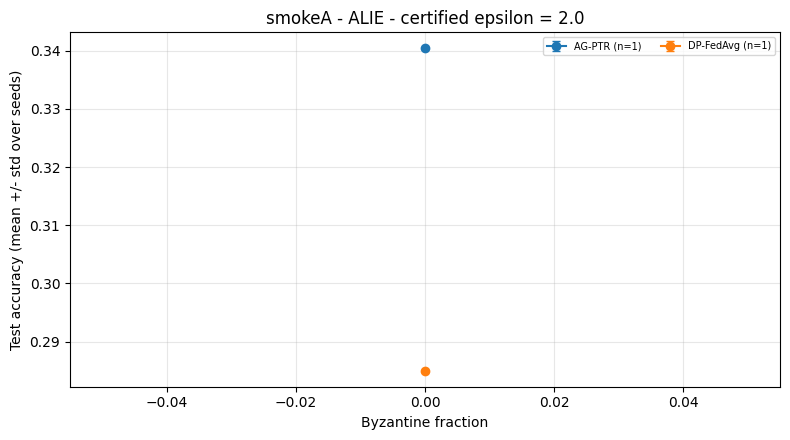

In [ ]:
# Cell 16a — JOB: smoke  (2 short runs)
run_job("smoke")          # runs only what is missing; safe to re-run
import_legacy("smoke")    # adds the paper's seed-0 rows to the CSV (once)
print_job_log("smoke")    # FULL LOG of every run of this job, all sessions, with timestamps
aggregate("smoke")        # mean +/- std over seeds, summary CSV, error-bar plots


JOB = grid | results file: /content/drive/MyDrive/agptr_runs/pA_results.csv
q = 0.016722 | sigma_dp = 0.9723 | AG-PTR: sigma_sel = 2.1742, sigma_rel = 1.0871 | certified epsilon = 2.000
0 runs already done, 294 to do
[1/294] seed=0 ALIE    f=0.00 DP-FedAvg                acc=0.7087 accept=1.000 (ok, 65s, ETA 318 min)
[2/294] seed=0 ALIE    f=0.00 FedVRDP-style            acc=0.7542 accept=1.000 (ok, 63s, ETA 311 min)
[3/294] seed=0 ALIE    f=0.00 Median                   acc=0.7698 accept=1.000 (ok, 140s, ETA 432 min)
[4/294] seed=0 ALIE    f=0.00 TrimmedMean              acc=0.8050 accept=1.000 (ok, 87s, ETA 428 min)
[5/294] seed=0 ALIE    f=0.00 Krum                     acc=0.7120 accept=1.000 (ok, 94s, ETA 432 min)
[6/294] seed=0 ALIE    f=0.00 SparseFed-style          acc=0.8037 accept=1.000 (ok, 103s, ETA 441 min)
[7/294] seed=0 ALIE    f=0.00 AG-PTR                   acc=0.7728 accept=0.944 (ok, 93s, ETA 440 min)
[8/294] seed=0 ALIE    f=0.10 DP-FedAvg                acc=0.6986 a

,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-08T06:21:55,0,ALIE,0.00,DP-FedAvg,0.7087,1.000000,65.0,ok,NaN,2.0
1,2026-09-08T06:22:58,0,ALIE,0.00,FedVRDP-style,0.7542,1.000000,62.6,ok,NaN,2.0
2,2026-09-08T06:25:17,0,ALIE,0.00,Median,0.7698,1.000000,139.5,ok,NaN,NaN
3,2026-09-08T06:26:44,0,ALIE,0.00,TrimmedMean,0.8050,1.000000,86.9,ok,NaN,NaN
4,2026-09-08T06:28:19,0,ALIE,0.00,Krum,0.7120,1.000000,94.5,ok,NaN,NaN
5,2026-09-08T06:30:02,0,ALIE,0.00,SparseFed-style,0.8037,1.000000,103.1,ok,NaN,NaN
6,2026-09-08T06:31:35,0,ALIE,0.00,AG-PTR,0.7728,0.944444,92.9,ok,1.087089,2.0
7,2026-09-08T06:32:36,0,ALIE,0.10,DP-FedAvg,0.6986,1.000000,60.8,ok,NaN,2.0
8,2026-09-08T06:33:34,0,ALIE,0.10,FedVRDP-style,0.7351,1.000000,58.5,ok,NaN,2.0
9,2026-09-08T06:35:57,0,ALIE,0.10,Median,0.7507,1.000000,142.8,ok,NaN,NaN


saved /content/drive/MyDrive/agptr_runs/pA_seed_summary.csv


,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,alie,ALIE,AG-PTR,0.00,0.7728,0.0,1,0.944444,NaN
1,alie,ALIE,AG-PTR,0.10,0.7507,0.0,1,0.905556,NaN
2,alie,ALIE,AG-PTR,0.20,0.7253,0.0,1,0.822222,NaN
3,alie,ALIE,AG-PTR,0.30,0.7631,0.0,1,0.616667,NaN
4,alie,ALIE,AG-PTR,0.40,0.7327,0.0,1,0.388889,NaN
...,...,...,...,...,...,...,...,...,...
289,sf,SF,TrimmedMean,0.20,0.6190,0.0,1,1.000000,NaN
290,sf,SF,TrimmedMean,0.30,0.5653,0.0,1,1.000000,NaN
291,sf,SF,TrimmedMean,0.40,0.1961,0.0,1,1.000000,NaN
292,sf,SF,TrimmedMean,0.49,0.1310,0.0,1,1.000000,NaN


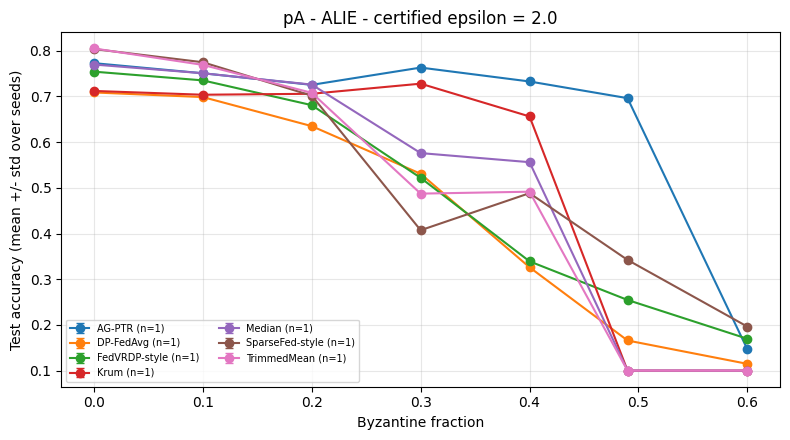

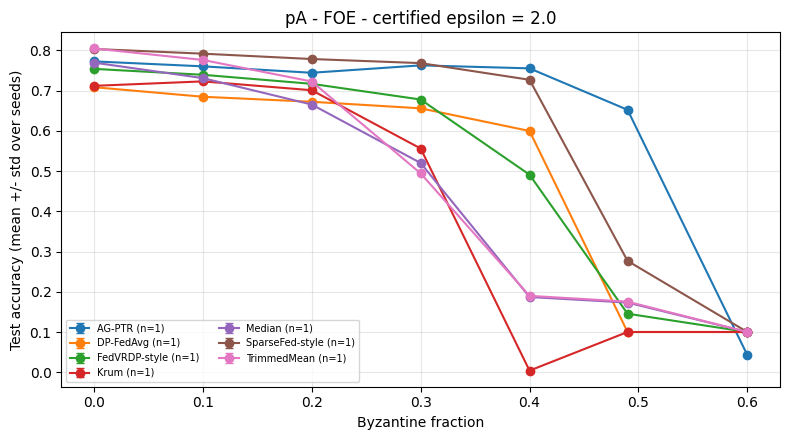

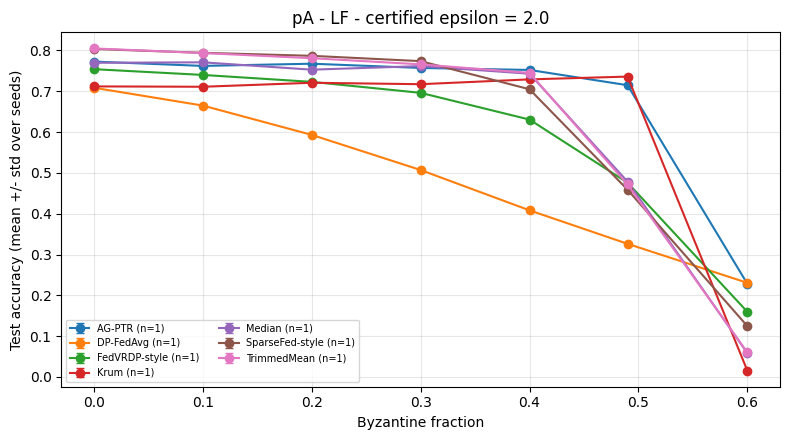

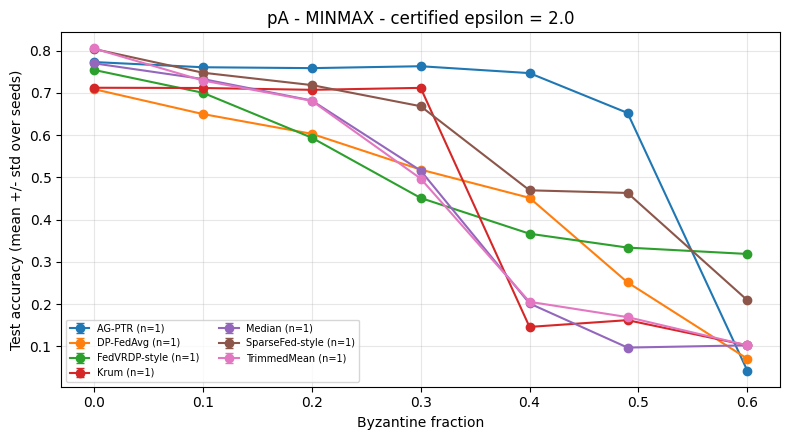

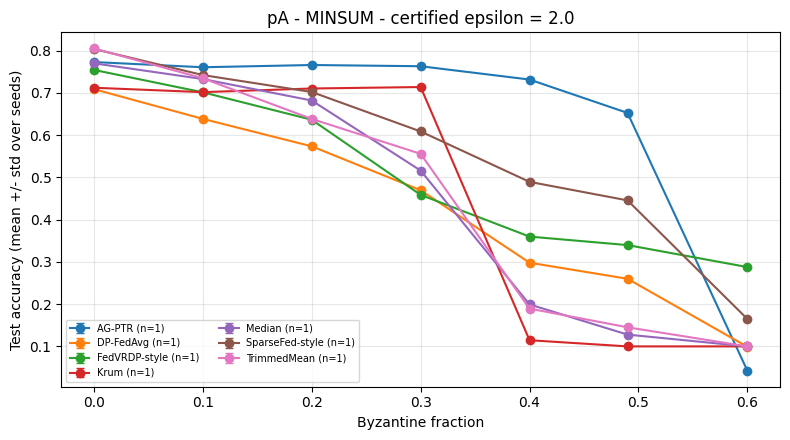

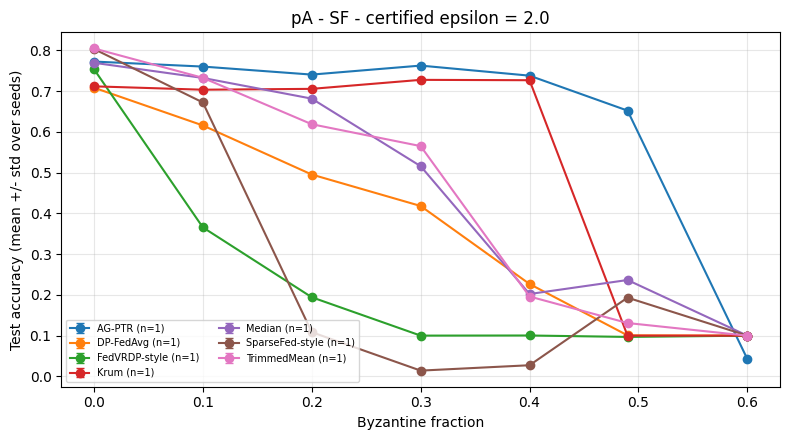

In [ ]:
# Cell 16b — JOB: grid  (294 runs: all seven methods, six attacks, seven fractions (Figure 2 row 1, Table II))
run_job("grid")          # runs only what is missing; safe to re-run
import_legacy("grid")    # adds the paper's seed-0 rows to the CSV (once)
print_job_log("grid")    # FULL LOG of every run of this job, all sessions, with timestamps
aggregate("grid")        # mean +/- std over seeds, summary CSV, error-bar plots


JOB = controls | results file: /content/drive/MyDrive/agptr_runs/pA_results.csv
q = 0.016722 | sigma_dp = 0.9723 | AG-PTR: sigma_sel = 2.1742, sigma_rel = 1.0871 | certified epsilon = 2.000
294 runs already done, 126 to do
[1/126] seed=0 ALIE    f=0.00 AnchoredClip-NoGate      acc=0.8007 accept=1.000 (ok, 81s, ETA 168 min)
[2/126] seed=0 ALIE    f=0.00 DP-FedAvg+Public         acc=0.7193 accept=n/a (ok, 80s, ETA 166 min)
[3/126] seed=0 ALIE    f=0.00 FLTrust                  acc=0.0827 accept=n/a (ok, 65s, ETA 154 min)
[4/126] seed=0 ALIE    f=0.10 AnchoredClip-NoGate      acc=0.7718 accept=1.000 (ok, 78s, ETA 155 min)
[5/126] seed=0 ALIE    f=0.10 DP-FedAvg+Public         acc=0.7046 accept=n/a (ok, 76s, ETA 153 min)
[6/126] seed=0 ALIE    f=0.10 FLTrust                  acc=0.8253 accept=n/a (ok, 63s, ETA 148 min)
[7/126] seed=0 ALIE    f=0.20 AnchoredClip-NoGate      acc=0.7159 accept=1.000 (ok, 72s, ETA 146 min)
[8/126] seed=0 ALIE    f=0.20 DP-FedAvg+Public         acc=0.6510 accep

,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-08T13:17:48,0,ALIE,0.00,AnchoredClip-NoGate,0.8007,1.0,80.7,ok,NaN,2.0
1,2026-09-08T13:19:09,0,ALIE,0.00,DP-FedAvg+Public,0.7193,NaN,80.1,ok,NaN,2.0
2,2026-09-08T13:20:14,0,ALIE,0.00,FLTrust,0.0827,NaN,65.2,ok,NaN,NaN
3,2026-09-08T13:21:32,0,ALIE,0.10,AnchoredClip-NoGate,0.7718,1.0,78.0,ok,NaN,2.0
4,2026-09-08T13:22:48,0,ALIE,0.10,DP-FedAvg+Public,0.7046,NaN,76.3,ok,NaN,2.0
5,2026-09-08T13:23:51,0,ALIE,0.10,FLTrust,0.8253,NaN,63.0,ok,NaN,NaN
6,2026-09-08T13:25:03,0,ALIE,0.20,AnchoredClip-NoGate,0.7159,1.0,71.9,ok,NaN,2.0
7,2026-09-08T13:26:13,0,ALIE,0.20,DP-FedAvg+Public,0.6510,NaN,69.6,ok,NaN,2.0
8,2026-09-08T13:27:10,0,ALIE,0.20,FLTrust,0.8191,NaN,56.9,ok,NaN,NaN
9,2026-09-08T13:28:15,0,ALIE,0.30,AnchoredClip-NoGate,0.6255,1.0,65.6,ok,NaN,2.0


saved /content/drive/MyDrive/agptr_runs/pA_seed_summary.csv


,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,alie,ALIE,AG-PTR,0.00,0.7728,0.0,1,0.944444,NaN
1,alie,ALIE,AG-PTR,0.10,0.7507,0.0,1,0.905556,NaN
2,alie,ALIE,AG-PTR,0.20,0.7253,0.0,1,0.822222,NaN
3,alie,ALIE,AG-PTR,0.30,0.7631,0.0,1,0.616667,NaN
4,alie,ALIE,AG-PTR,0.40,0.7327,0.0,1,0.388889,NaN
...,...,...,...,...,...,...,...,...,...
415,sf,SF,TrimmedMean,0.20,0.6190,0.0,1,1.000000,NaN
416,sf,SF,TrimmedMean,0.30,0.5653,0.0,1,1.000000,NaN
417,sf,SF,TrimmedMean,0.40,0.1961,0.0,1,1.000000,NaN
418,sf,SF,TrimmedMean,0.49,0.1310,0.0,1,1.000000,NaN


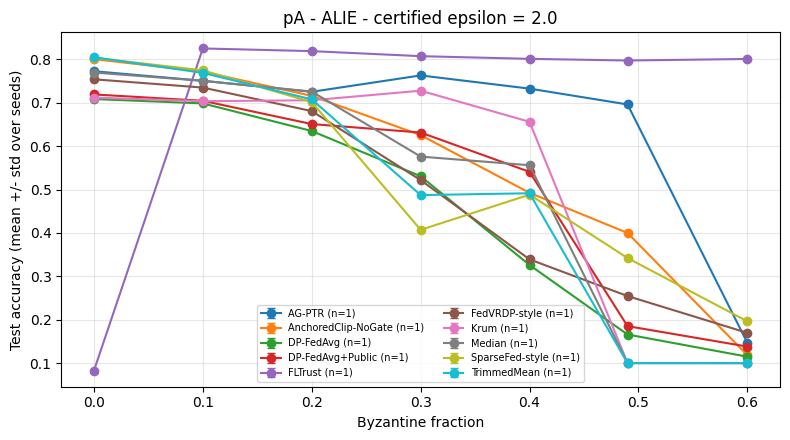

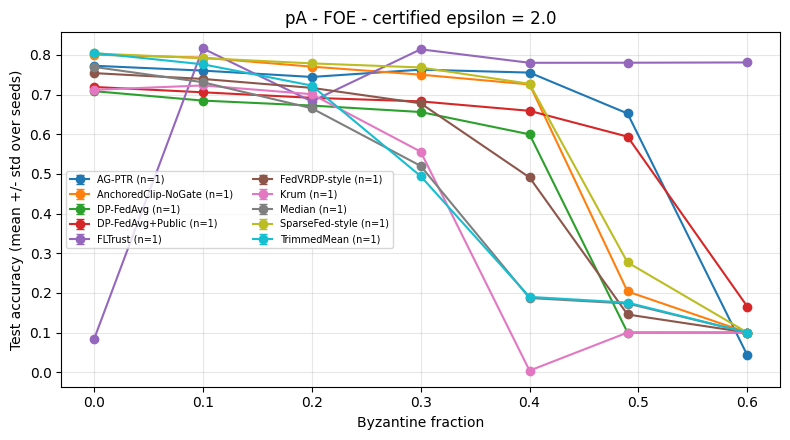

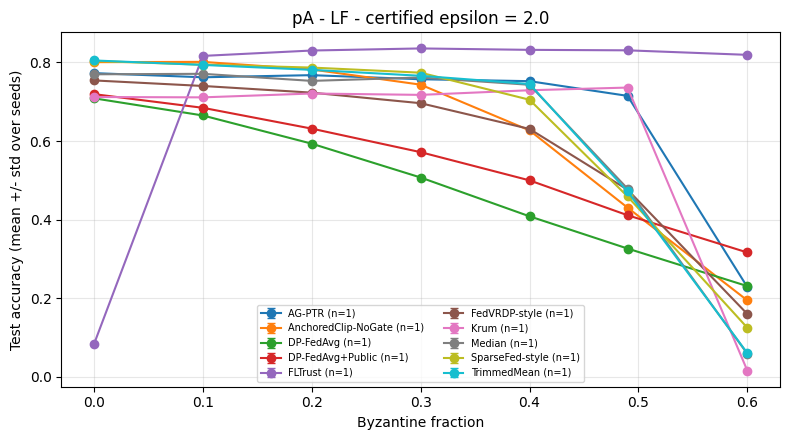

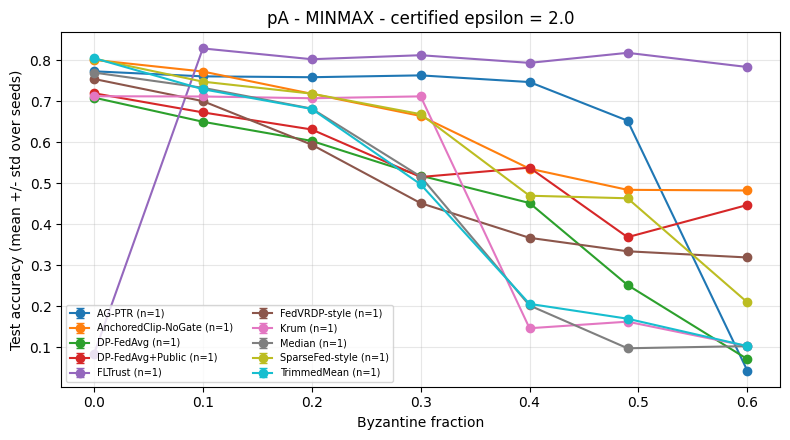

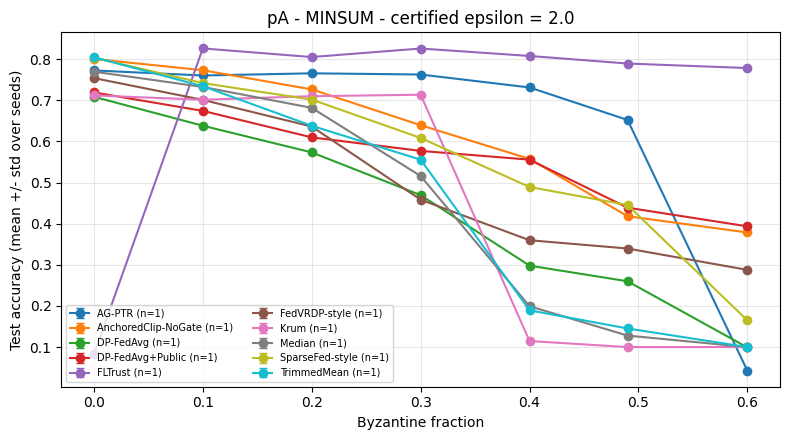

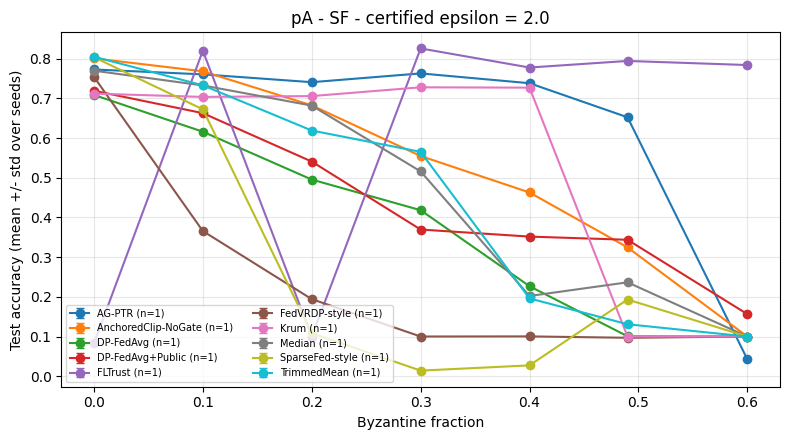

In [ ]:
# Cell 16c — JOB: controls  (126 runs: anchored clipping without the gate, DP-FedAvg + public anchor, FLTrust)
run_job("controls")          # runs only what is missing; safe to re-run
import_legacy("controls")    # adds the paper's seed-0 rows to the CSV (once)
print_job_log("controls")    # FULL LOG of every run of this job, all sessions, with timestamps
aggregate("controls")        # mean +/- std over seeds, summary CSV, error-bar plots


JOB = publiconly | results file: /content/drive/MyDrive/agptr_runs/pA_results.csv
q = 0.016722 | sigma_dp = 0.9723 | AG-PTR: sigma_sel = 2.1742, sigma_rel = 1.0871 | certified epsilon = 2.000
420 runs already done, 3 to do
[1/3] seed=0 ALIE    f=0.00 PublicOnly               acc=0.7091 accept=n/a (ok, 17s, ETA 1 min)
[2/3] seed=1 ALIE    f=0.00 PublicOnly               acc=0.6966 accept=n/a (ok, 17s, ETA 0 min)
[3/3] seed=2 ALIE    f=0.00 PublicOnly               acc=0.7074 accept=n/a (ok, 17s, ETA 0 min)
done for now: /content/drive/MyDrive/agptr_runs/pA_results.csv
no legacy import under Poisson sampling: every reported row is a new run
FULL LOG for job 'publiconly': 3 completed runs over all sessions (3 ok, 0 error) - file /content/drive/MyDrive/agptr_runs/pA_results.csv


,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-08T15:32:40,0,ALIE,0.0,PublicOnly,0.7091,NaN,16.6,ok,NaN,NaN
1,2026-09-08T15:32:57,1,ALIE,0.0,PublicOnly,0.6966,NaN,17.0,ok,NaN,NaN
2,2026-09-08T15:33:13,2,ALIE,0.0,PublicOnly,0.7074,NaN,16.7,ok,NaN,NaN


saved /content/drive/MyDrive/agptr_runs/pA_seed_summary.csv


,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,alie,ALIE,AG-PTR,0.00,0.7728,0.0,1,0.944444,NaN
1,alie,ALIE,AG-PTR,0.10,0.7507,0.0,1,0.905556,NaN
2,alie,ALIE,AG-PTR,0.20,0.7253,0.0,1,0.822222,NaN
3,alie,ALIE,AG-PTR,0.30,0.7631,0.0,1,0.616667,NaN
4,alie,ALIE,AG-PTR,0.40,0.7327,0.0,1,0.388889,NaN
...,...,...,...,...,...,...,...,...,...
416,sf,SF,TrimmedMean,0.20,0.6190,0.0,1,1.000000,NaN
417,sf,SF,TrimmedMean,0.30,0.5653,0.0,1,1.000000,NaN
418,sf,SF,TrimmedMean,0.40,0.1961,0.0,1,1.000000,NaN
419,sf,SF,TrimmedMean,0.49,0.1310,0.0,1,1.000000,NaN


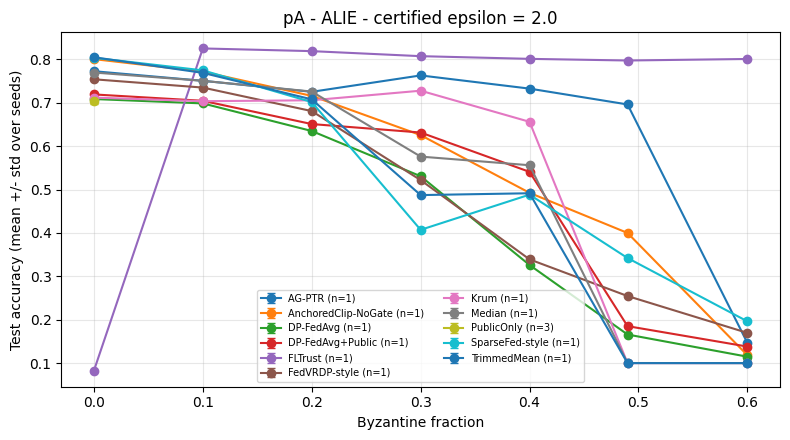

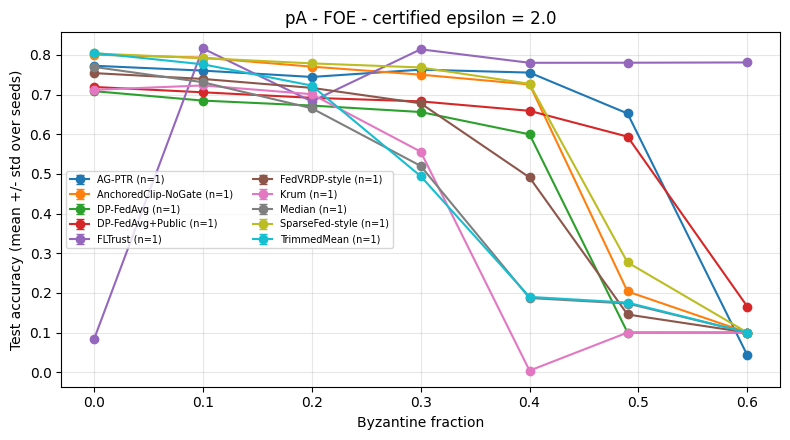

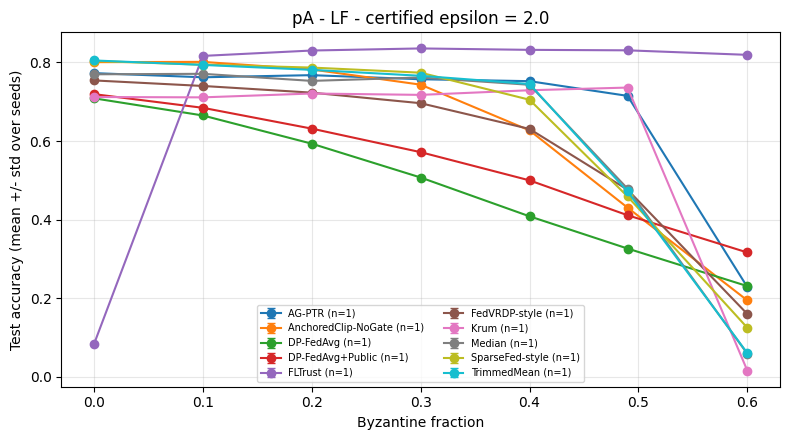

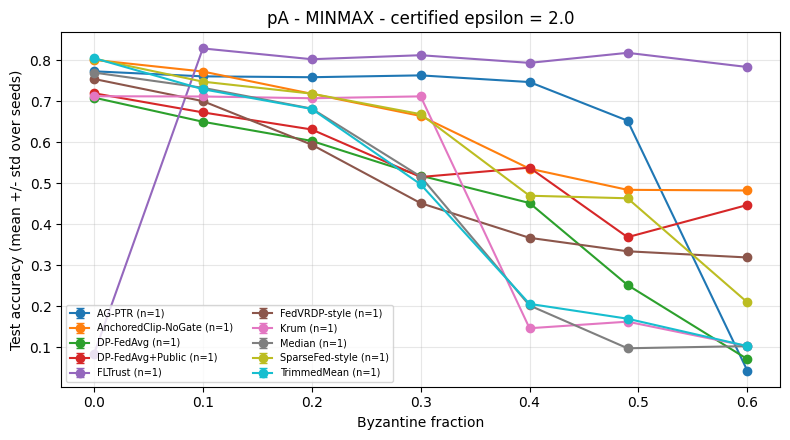

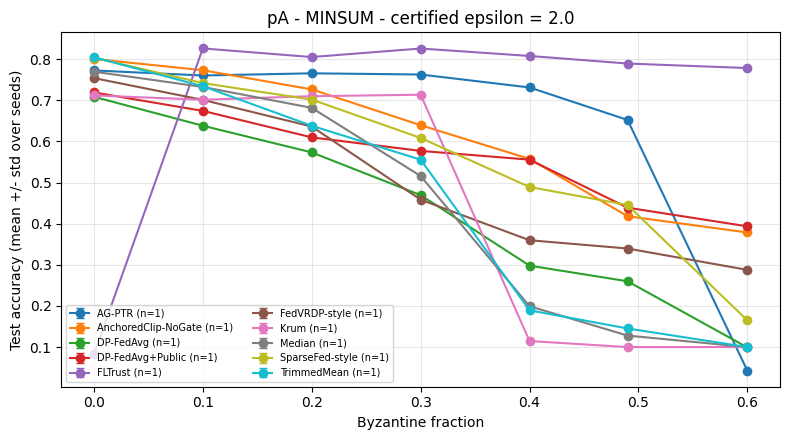

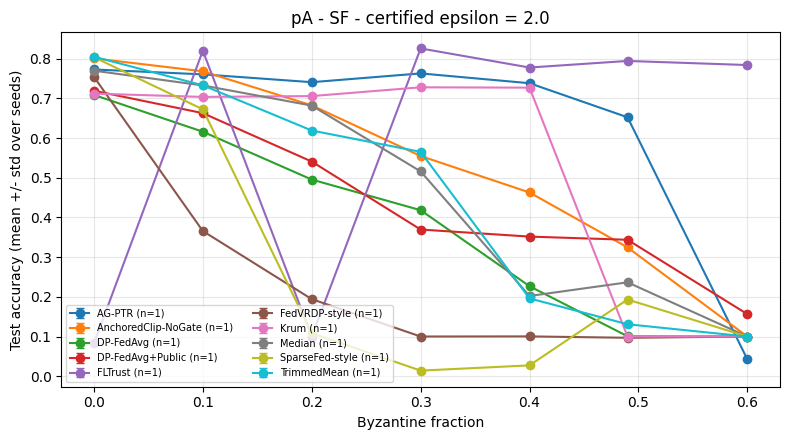

In [ ]:
# Cell 16d — JOB: publiconly  (3 runs: the public anchor alone)
run_job("publiconly")          # runs only what is missing; safe to re-run
import_legacy("publiconly")    # adds the paper's seed-0 rows to the CSV (once)
print_job_log("publiconly")    # FULL LOG of every run of this job, all sessions, with timestamps
aggregate("publiconly")        # mean +/- std over seeds, summary CSV, error-bar plots


JOB = inball | results file: /content/drive/MyDrive/agptr_runs/pA_results.csv
q = 0.016722 | sigma_dp = 0.9723 | AG-PTR: sigma_sel = 2.1742, sigma_rel = 1.0871 | certified epsilon = 2.000
423 runs already done, 7 to do
[1/7] seed=0 InBall  f=0.00 AG-PTR                   acc=0.7728 accept=0.944 (ok, 90s, ETA 9 min)
[2/7] seed=0 InBall  f=0.10 AG-PTR                   acc=0.7406 accept=0.867 (ok, 84s, ETA 7 min)
[3/7] seed=0 InBall  f=0.20 AG-PTR                   acc=0.7445 accept=0.944 (ok, 80s, ETA 6 min)
[4/7] seed=0 InBall  f=0.30 AG-PTR                   acc=0.7043 accept=0.983 (ok, 75s, ETA 4 min)
[5/7] seed=0 InBall  f=0.40 AG-PTR                   acc=0.5335 accept=1.000 (ok, 71s, ETA 3 min)
[6/7] seed=0 InBall  f=0.49 AG-PTR                   acc=0.6463 accept=1.000 (ok, 66s, ETA 1 min)
[7/7] seed=0 InBall  f=0.60 AG-PTR                   acc=0.6148 accept=1.000 (ok, 60s, ETA 0 min)
done for now: /content/drive/MyDrive/agptr_runs/pA_results.csv
no legacy import under Poisson s

,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-08T15:34:47,0,InBall,0.00,AG-PTR,0.7728,0.944444,89.9,ok,1.087089,2.0
1,2026-09-08T15:36:12,0,InBall,0.10,AG-PTR,0.7406,0.866667,84.4,ok,1.087089,2.0
2,2026-09-08T15:37:32,0,InBall,0.20,AG-PTR,0.7445,0.944444,79.9,ok,1.087089,2.0
3,2026-09-08T15:38:47,0,InBall,0.30,AG-PTR,0.7043,0.983333,75.0,ok,1.087089,2.0
4,2026-09-08T15:39:58,0,InBall,0.40,AG-PTR,0.5335,1.000000,71.2,ok,1.087089,2.0
5,2026-09-08T15:41:04,0,InBall,0.49,AG-PTR,0.6463,1.000000,66.0,ok,1.087089,2.0
6,2026-09-08T15:42:04,0,InBall,0.60,AG-PTR,0.6148,1.000000,59.7,ok,1.087089,2.0


saved /content/drive/MyDrive/agptr_runs/pA_seed_summary.csv


,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,alie,ALIE,AG-PTR,0.00,0.7728,0.0,1,0.944444,NaN
1,alie,ALIE,AG-PTR,0.10,0.7507,0.0,1,0.905556,NaN
2,alie,ALIE,AG-PTR,0.20,0.7253,0.0,1,0.822222,NaN
3,alie,ALIE,AG-PTR,0.30,0.7631,0.0,1,0.616667,NaN
4,alie,ALIE,AG-PTR,0.40,0.7327,0.0,1,0.388889,NaN
...,...,...,...,...,...,...,...,...,...
423,sf,SF,TrimmedMean,0.20,0.6190,0.0,1,1.000000,NaN
424,sf,SF,TrimmedMean,0.30,0.5653,0.0,1,1.000000,NaN
425,sf,SF,TrimmedMean,0.40,0.1961,0.0,1,1.000000,NaN
426,sf,SF,TrimmedMean,0.49,0.1310,0.0,1,1.000000,NaN


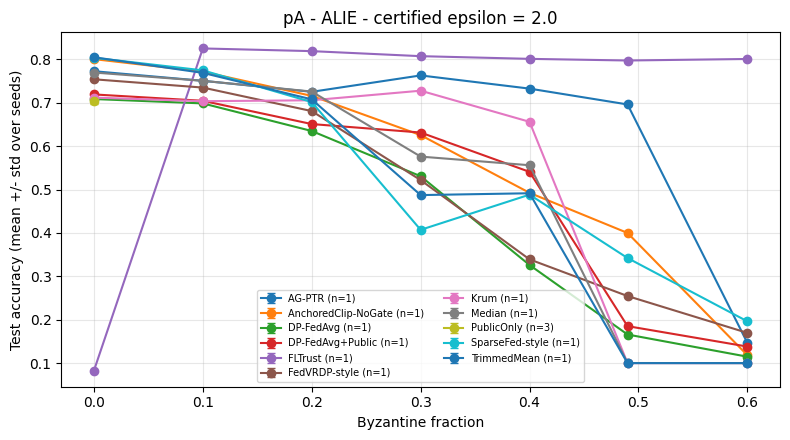

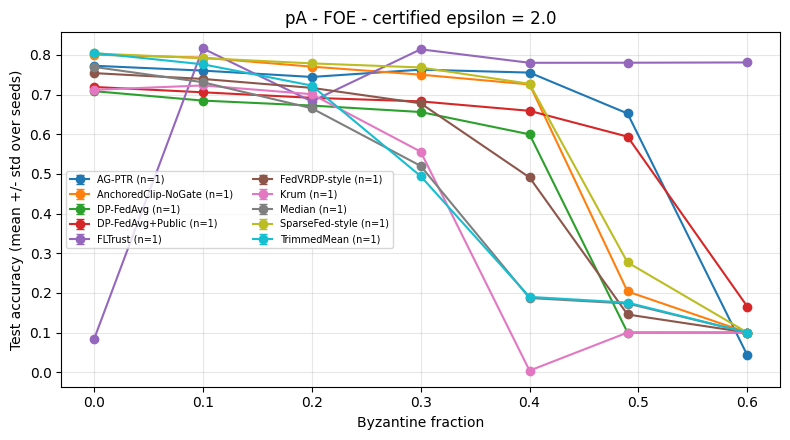

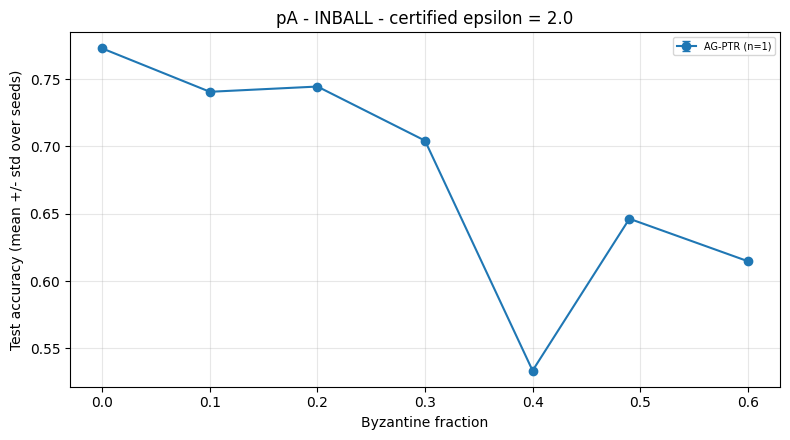

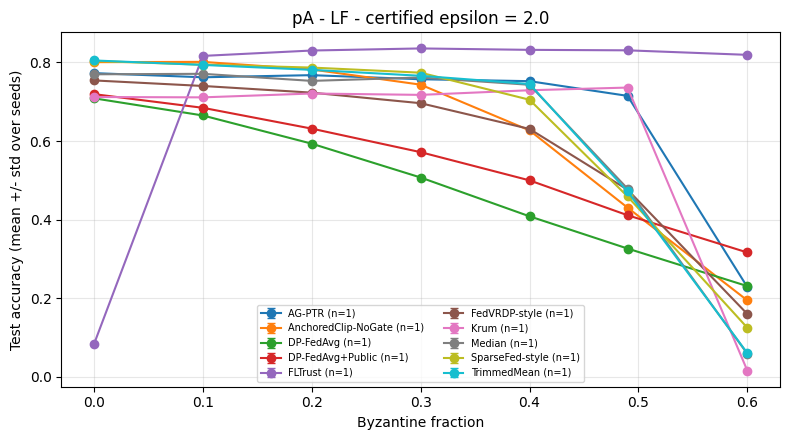

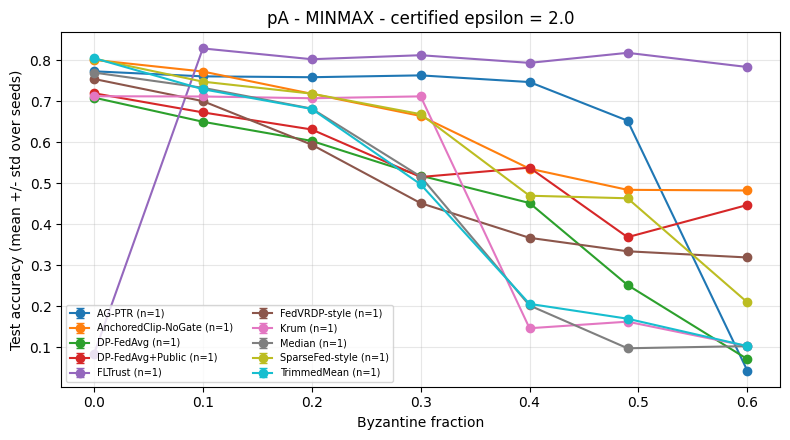

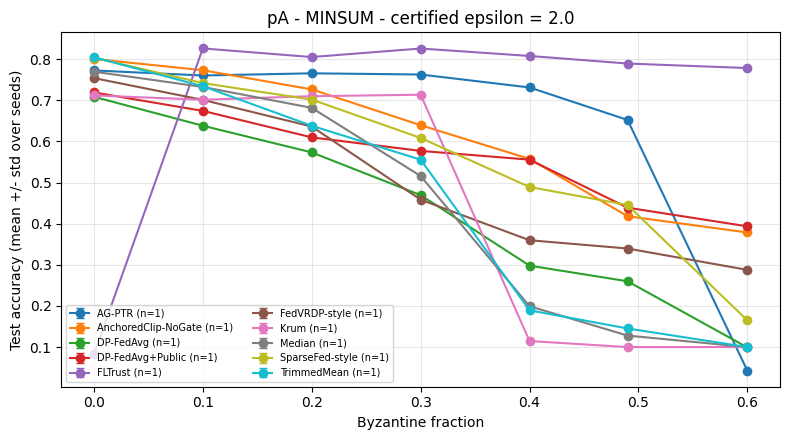

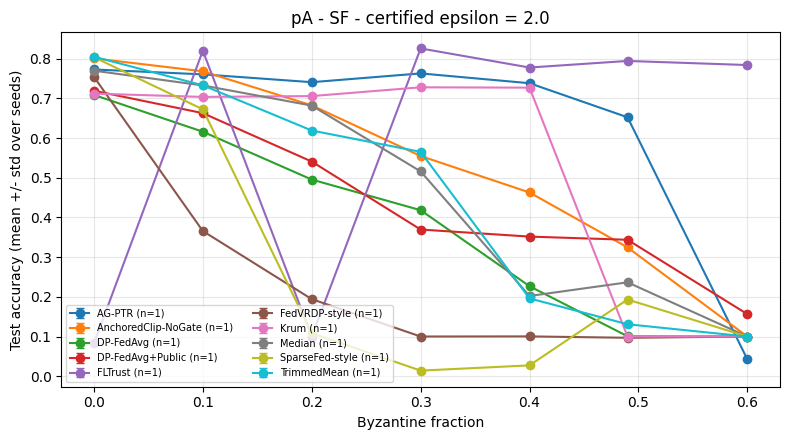

In [ ]:
# Cell 16e — JOB: inball  (7 runs: defense-aware in-ball attack against AG-PTR)
run_job("inball")          # runs only what is missing; safe to re-run
import_legacy("inball")    # adds the paper's seed-0 rows to the CSV (once)
print_job_log("inball")    # FULL LOG of every run of this job, all sessions, with timestamps
aggregate("inball")        # mean +/- std over seeds, summary CSV, error-bar plots


JOB = seeds | results file: /content/drive/MyDrive/agptr_runs/pA_results.csv
q = 0.016722 | sigma_dp = 0.9723 | AG-PTR: sigma_sel = 2.1742, sigma_rel = 1.0871 | certified epsilon = 2.000
430 runs already done, 40 to do
[1/40] seed=1 ALIE    f=0.00 AG-PTR                   acc=0.7482 accept=0.850 (ok, 88s, ETA 58 min)
[2/40] seed=1 ALIE    f=0.00 DP-FedAvg                acc=0.7219 accept=1.000 (ok, 62s, ETA 48 min)
[3/40] seed=1 ALIE    f=0.00 TrimmedMean              acc=0.7817 accept=1.000 (ok, 82s, ETA 48 min)
[4/40] seed=1 ALIE    f=0.00 Krum                     acc=0.7193 accept=1.000 (ok, 87s, ETA 48 min)
[5/40] seed=1 ALIE    f=0.00 SparseFed-style          acc=0.7800 accept=1.000 (ok, 98s, ETA 49 min)
[6/40] seed=1 ALIE    f=0.40 AG-PTR                   acc=0.6878 accept=0.328 (ok, 64s, ETA 46 min)
[7/40] seed=1 ALIE    f=0.40 DP-FedAvg                acc=0.4002 accept=1.000 (ok, 43s, ETA 41 min)
[8/40] seed=1 ALIE    f=0.40 TrimmedMean              acc=0.2027 accept=1.000 (ok

,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-08T15:43:36,1,ALIE,0.0,AG-PTR,0.7482,0.850000,88.5,ok,1.087089,2.0
1,2026-09-08T15:44:38,1,ALIE,0.0,DP-FedAvg,0.7219,1.000000,61.9,ok,NaN,2.0
2,2026-09-08T15:46:00,1,ALIE,0.0,TrimmedMean,0.7817,1.000000,81.9,ok,NaN,NaN
3,2026-09-08T15:47:27,1,ALIE,0.0,Krum,0.7193,1.000000,87.4,ok,NaN,NaN
4,2026-09-08T15:49:06,1,ALIE,0.0,SparseFed-style,0.7800,1.000000,98.2,ok,NaN,NaN
5,2026-09-08T15:50:10,1,ALIE,0.4,AG-PTR,0.6878,0.327778,64.2,ok,1.087089,2.0
6,2026-09-08T15:50:52,1,ALIE,0.4,DP-FedAvg,0.4002,1.000000,42.7,ok,NaN,2.0
7,2026-09-08T15:52:52,1,ALIE,0.4,TrimmedMean,0.2027,1.000000,119.5,ok,NaN,NaN
8,2026-09-08T15:54:03,1,ALIE,0.4,Krum,0.3748,1.000000,70.5,ok,NaN,NaN
9,2026-09-08T15:55:25,1,ALIE,0.4,SparseFed-style,0.2852,1.000000,82.1,ok,NaN,NaN


saved /content/drive/MyDrive/agptr_runs/pA_seed_summary.csv


,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,alie,ALIE,AG-PTR,0.00,0.760500,0.012300,3,0.900000,0.047467
1,alie,ALIE,AG-PTR,0.10,0.750700,0.000000,1,0.905556,NaN
2,alie,ALIE,AG-PTR,0.20,0.725300,0.000000,1,0.822222,NaN
3,alie,ALIE,AG-PTR,0.30,0.763100,0.000000,1,0.616667,NaN
4,alie,ALIE,AG-PTR,0.40,0.714467,0.023608,3,0.331481,0.055648
...,...,...,...,...,...,...,...,...,...
423,sf,SF,TrimmedMean,0.20,0.619000,0.000000,1,1.000000,NaN
424,sf,SF,TrimmedMean,0.30,0.565300,0.000000,1,1.000000,NaN
425,sf,SF,TrimmedMean,0.40,0.196100,0.000000,1,1.000000,NaN
426,sf,SF,TrimmedMean,0.49,0.131000,0.000000,1,1.000000,NaN


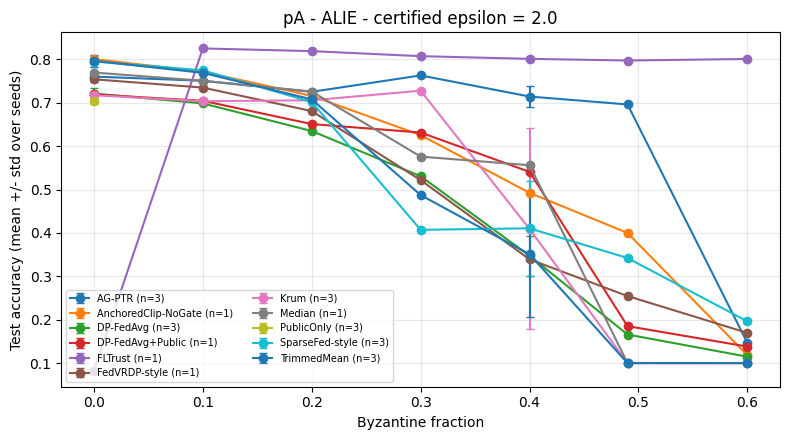

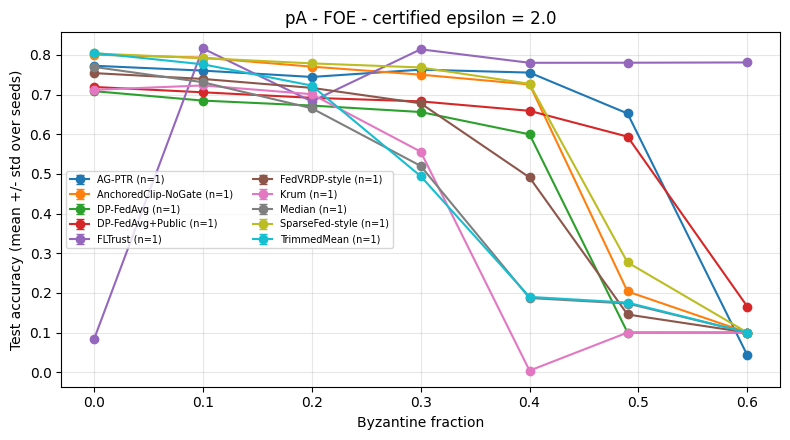

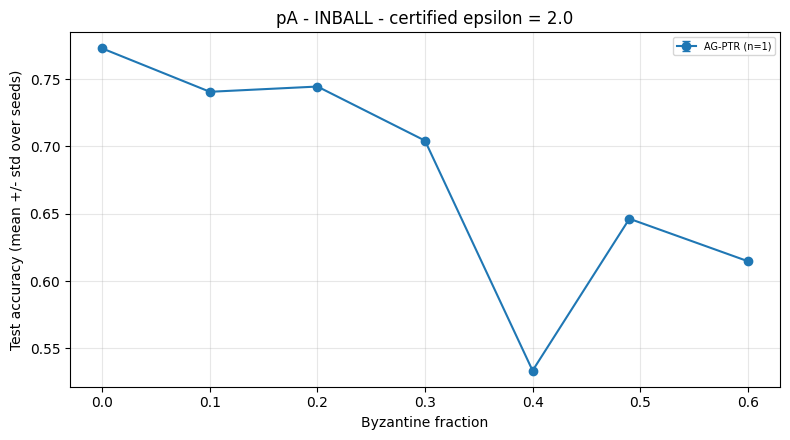

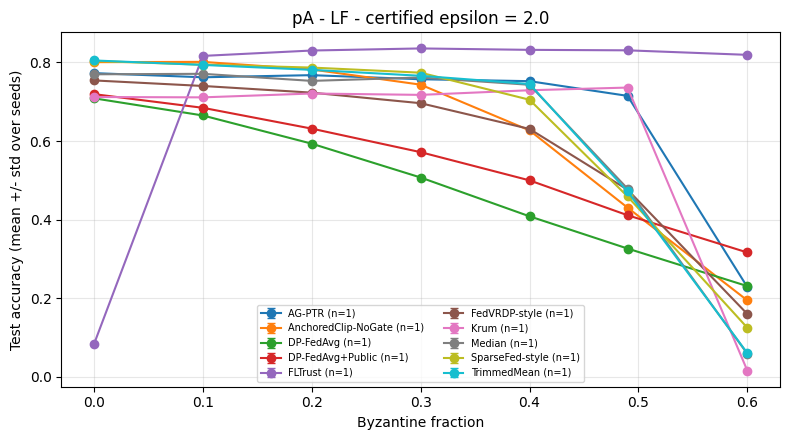

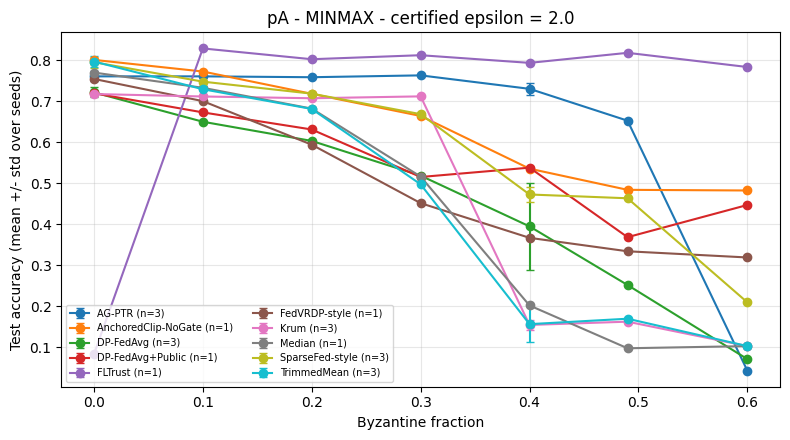

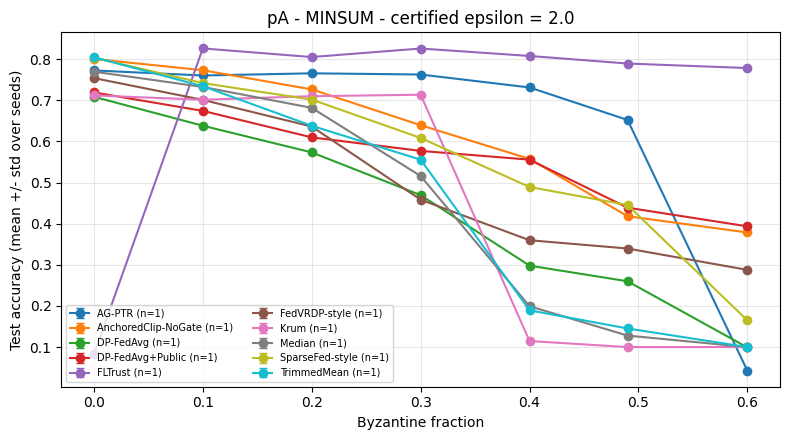

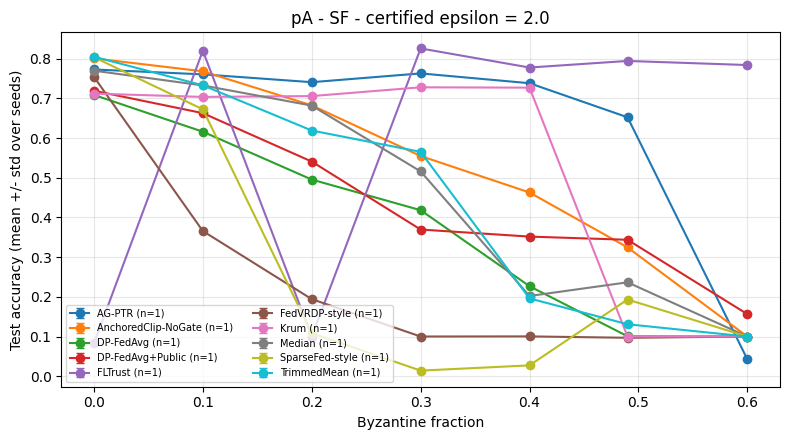

In [ ]:
# Cell 16f — JOB: seeds  (40 runs: seeds 1-2 for AG-PTR and the four strongest baselines on the headline cells)
run_job("seeds")          # runs only what is missing; safe to re-run
import_legacy("seeds")    # adds the paper's seed-0 rows to the CSV (once)
print_job_log("seeds")    # FULL LOG of every run of this job, all sessions, with timestamps
aggregate("seeds")        # mean +/- std over seeds, summary CSV, error-bar plots


moved 42 preliminary FLTrust rows to pA_results_fltrust_v1.csv
JOB = fltrust | results file: /content/drive/MyDrive/agptr_runs/pA_results.csv
q = 0.016722 | sigma_dp = 0.9723 | AG-PTR: sigma_sel = 2.1742, sigma_rel = 1.0871 | certified epsilon = 2.000
428 runs already done, 42 to do
[1/42] seed=0 ALIE    f=0.00 FLTrust                  acc=0.7505 accept=n/a (ok, 73s, ETA 50 min)
[2/42] seed=0 ALIE    f=0.10 FLTrust                  acc=0.7478 accept=n/a (ok, 67s, ETA 47 min)
[3/42] seed=0 ALIE    f=0.20 FLTrust                  acc=0.7485 accept=n/a (ok, 61s, ETA 44 min)
[4/42] seed=0 ALIE    f=0.30 FLTrust                  acc=0.7481 accept=n/a (ok, 56s, ETA 41 min)
[5/42] seed=0 ALIE    f=0.40 FLTrust                  acc=0.7483 accept=n/a (ok, 50s, ETA 38 min)
[6/42] seed=0 ALIE    f=0.49 FLTrust                  acc=0.7474 accept=n/a (ok, 45s, ETA 35 min)
[7/42] seed=0 ALIE    f=0.60 FLTrust                  acc=0.7459 accept=n/a (ok, 39s, ETA 33 min)
[8/42] seed=0 SF      f=0.00 F

,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-10T00:11:56,0,ALIE,0.00,FLTrust,0.7505,NaN,73.2,ok,NaN,NaN
1,2026-09-10T00:13:03,0,ALIE,0.10,FLTrust,0.7478,NaN,66.9,ok,NaN,NaN
2,2026-09-10T00:14:04,0,ALIE,0.20,FLTrust,0.7485,NaN,60.7,ok,NaN,NaN
3,2026-09-10T00:14:59,0,ALIE,0.30,FLTrust,0.7481,NaN,55.9,ok,NaN,NaN
4,2026-09-10T00:15:49,0,ALIE,0.40,FLTrust,0.7483,NaN,49.7,ok,NaN,NaN
5,2026-09-10T00:16:34,0,ALIE,0.49,FLTrust,0.7474,NaN,45.0,ok,NaN,NaN
6,2026-09-10T00:17:13,0,ALIE,0.60,FLTrust,0.7459,NaN,39.2,ok,NaN,NaN
7,2026-09-10T00:18:24,0,SF,0.00,FLTrust,0.7505,NaN,70.6,ok,NaN,NaN
8,2026-09-10T00:19:30,0,SF,0.10,FLTrust,0.7472,NaN,66.0,ok,NaN,NaN
9,2026-09-10T00:20:30,0,SF,0.20,FLTrust,0.7452,NaN,60.0,ok,NaN,NaN


saved /content/drive/MyDrive/agptr_runs/pA_seed_summary.csv


,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,alie,ALIE,AG-PTR,0.00,0.760500,0.012300,3,0.900000,0.047467
1,alie,ALIE,AG-PTR,0.10,0.750700,0.000000,1,0.905556,NaN
2,alie,ALIE,AG-PTR,0.20,0.725300,0.000000,1,0.822222,NaN
3,alie,ALIE,AG-PTR,0.30,0.763100,0.000000,1,0.616667,NaN
4,alie,ALIE,AG-PTR,0.40,0.714467,0.023608,3,0.331481,0.055648
...,...,...,...,...,...,...,...,...,...
423,sf,SF,TrimmedMean,0.20,0.619000,0.000000,1,1.000000,NaN
424,sf,SF,TrimmedMean,0.30,0.565300,0.000000,1,1.000000,NaN
425,sf,SF,TrimmedMean,0.40,0.196100,0.000000,1,1.000000,NaN
426,sf,SF,TrimmedMean,0.49,0.131000,0.000000,1,1.000000,NaN


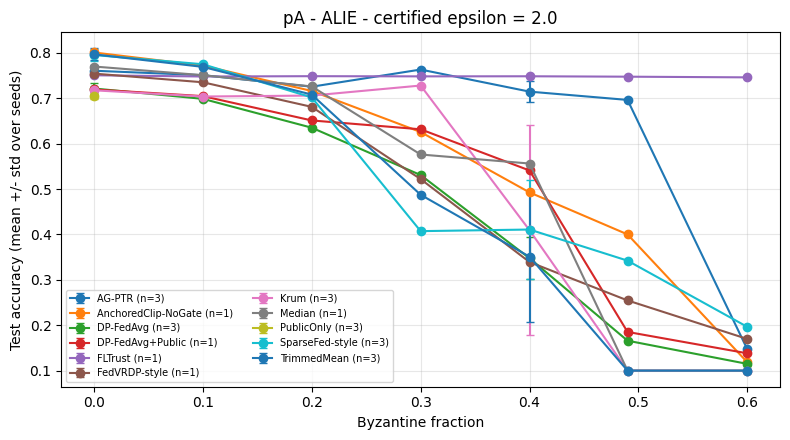

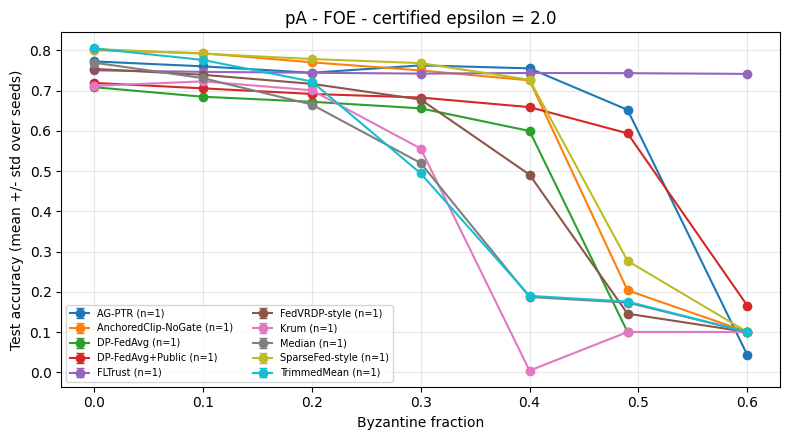

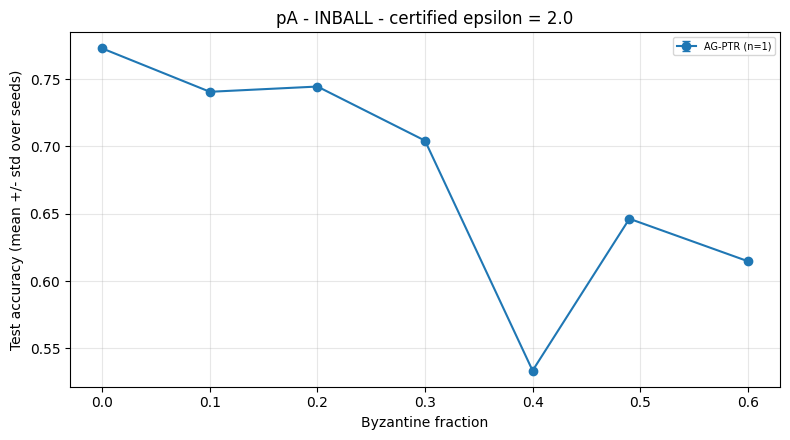

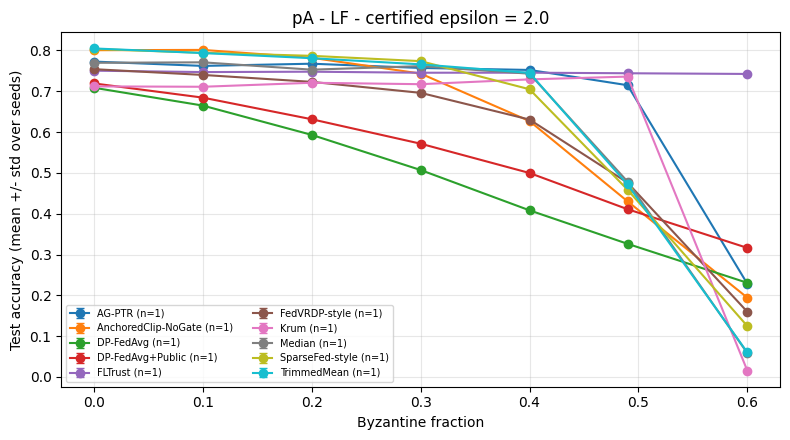

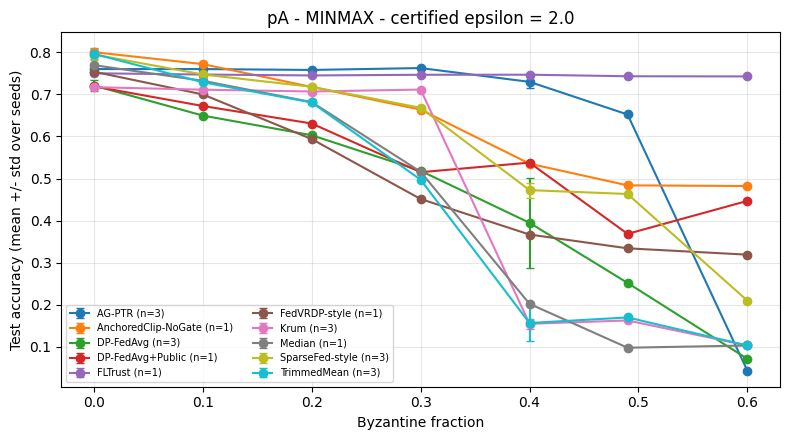

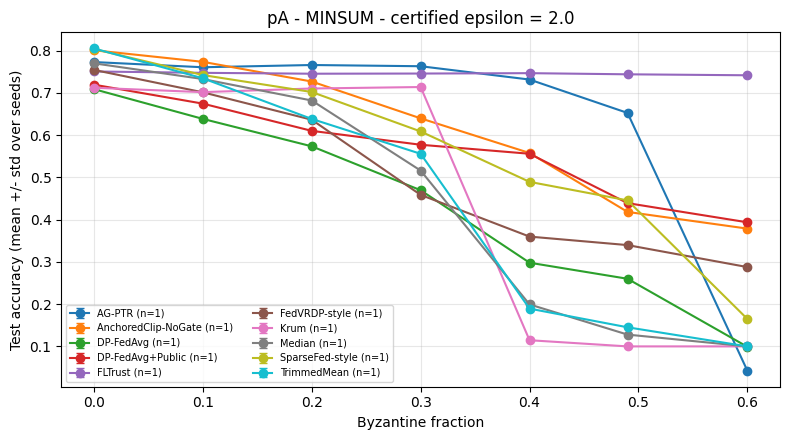

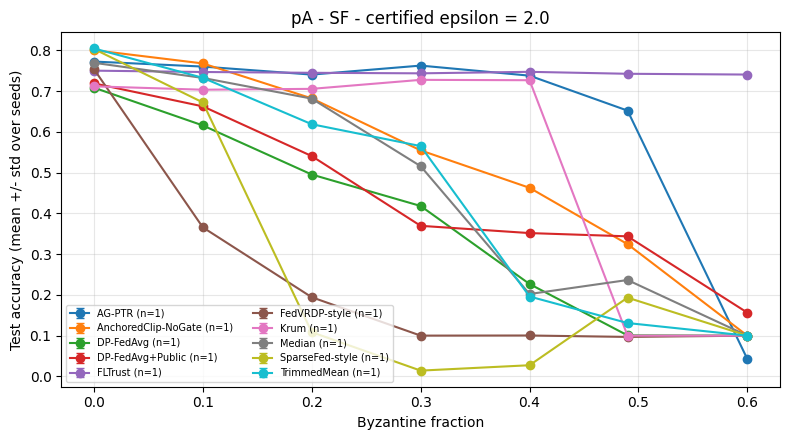

In [ ]:
# Cell 16g — FLTrust with the final root-update construction (42 runs)
# Rows of the preliminary FLTrust construction (root update trained for a full public epoch) are moved to
# pA_results_fltrust_v1.csv and replaced by runs of the construction in Cell 13.6.
_csv = os.path.join(RESULTS_DIR, "pA_results.csv"); _df = pd.read_csv(_csv)
_old = _df[_df["method"] == "FLTrust"]
if len(_old):
    _old.to_csv(os.path.join(RESULTS_DIR, "pA_results_fltrust_v1.csv"), index=False)
    _df[_df["method"] != "FLTrust"].to_csv(_csv, index=False)
    print("moved %d preliminary FLTrust rows to pA_results_fltrust_v1.csv" % len(_old))
run_job("fltrust")
print_job_log("fltrust")
aggregate("fltrust")


JOB = inball_seeds | results file: /content/drive/MyDrive/agptr_runs/pA_results.csv
q = 0.016722 | sigma_dp = 0.9723 | AG-PTR: sigma_sel = 2.1742, sigma_rel = 1.0871 | certified epsilon = 2.000
0 runs already done, 6 to do
[1/6] seed=1 InBall  f=0.30 AG-PTR                   acc=0.6859 accept=0.972 (ok, 87s, ETA 7 min)
[2/6] seed=1 InBall  f=0.40 AG-PTR                   acc=0.6714 accept=1.000 (ok, 79s, ETA 6 min)
[3/6] seed=1 InBall  f=0.49 AG-PTR                   acc=0.6566 accept=1.000 (ok, 74s, ETA 4 min)
[4/6] seed=2 InBall  f=0.30 AG-PTR                   acc=0.5858 accept=0.994 (ok, 87s, ETA 3 min)
[5/6] seed=2 InBall  f=0.40 AG-PTR                   acc=0.6530 accept=1.000 (ok, 81s, ETA 1 min)
[6/6] seed=2 InBall  f=0.49 AG-PTR                   acc=0.6297 accept=1.000 (ok, 75s, ETA 0 min)
done for now: /content/drive/MyDrive/agptr_runs/pA_results.csv
FULL LOG for job 'inball_seeds': 6 completed runs over all sessions (6 ok, 0 error) - file /content/drive/MyDrive/agptr_runs/p

,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-10T05:35:23,1,InBall,0.30,AG-PTR,0.6859,0.972222,87.1,ok,1.087089,2.0
1,2026-09-10T05:36:42,1,InBall,0.40,AG-PTR,0.6714,1.000000,79.3,ok,1.087089,2.0
2,2026-09-10T05:37:57,1,InBall,0.49,AG-PTR,0.6566,1.000000,74.4,ok,1.087089,2.0
3,2026-09-10T05:39:24,2,InBall,0.30,AG-PTR,0.5858,0.994444,86.7,ok,1.087089,2.0
4,2026-09-10T05:40:45,2,InBall,0.40,AG-PTR,0.6530,1.000000,81.3,ok,1.087089,2.0
5,2026-09-10T05:42:00,2,InBall,0.49,AG-PTR,0.6297,1.000000,75.1,ok,1.087089,2.0


saved /content/drive/MyDrive/agptr_runs/pA_seed_summary.csv


,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,inball,InBall,AG-PTR,0.30,0.63585,0.070781,2,0.983333,0.015713
1,inball,InBall,AG-PTR,0.40,0.66220,0.013011,2,1.000000,0.000000
2,inball,InBall,AG-PTR,0.49,0.64315,0.019021,2,1.000000,0.000000


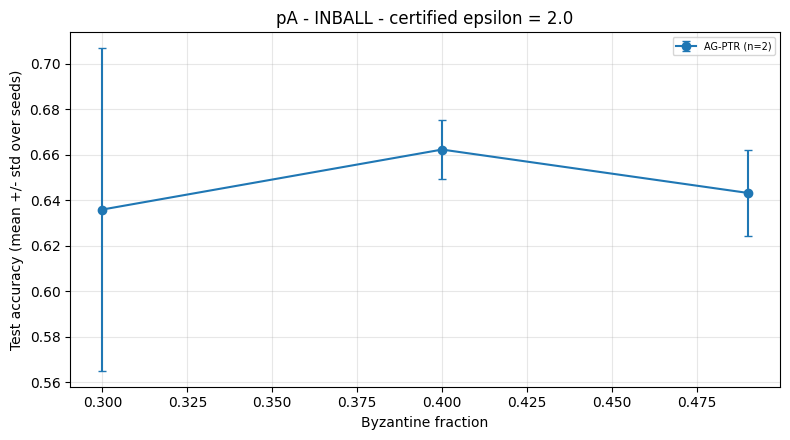

In [ ]:
# Cell 16h — in-ball attack, seeds 1-2 at f = 0.3 / 0.4 / 0.49 (6 runs)
run_job("inball_seeds")
print_job_log("inball_seeds")
aggregate("inball_seeds")


JOB = fedvrdp | results file: /content/drive/MyDrive/agptr_runs/pA_results.csv
q = 0.016722 | sigma_dp = 0.9723 | AG-PTR: sigma_sel = 2.1742, sigma_rel = 1.0871 | certified epsilon = 2.000
6 runs already done, 42 to do
[1/42] seed=0 ALIE    f=0.00 FedVRDP                  acc=0.7739 accept=1.000 (ok, 69s, ETA 47 min)
[2/42] seed=0 ALIE    f=0.10 FedVRDP                  acc=0.7574 accept=1.000 (ok, 66s, ETA 45 min)
[3/42] seed=0 ALIE    f=0.20 FedVRDP                  acc=0.7167 accept=1.000 (ok, 58s, ETA 42 min)
[4/42] seed=0 ALIE    f=0.30 FedVRDP                  acc=0.6595 accept=1.000 (ok, 52s, ETA 39 min)
[5/42] seed=0 ALIE    f=0.40 FedVRDP                  acc=0.5254 accept=1.000 (ok, 44s, ETA 36 min)
[6/42] seed=0 ALIE    f=0.49 FedVRDP                  acc=0.3617 accept=1.000 (ok, 38s, ETA 33 min)
[7/42] seed=0 ALIE    f=0.60 FedVRDP                  acc=0.1474 accept=1.000 (ok, 30s, ETA 30 min)
[8/42] seed=0 SF      f=0.00 FedVRDP                  acc=0.7739 accept=1.000 (ok

,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-10T05:43:12,0,ALIE,0.00,FedVRDP,0.7739,1.0,69.2,ok,NaN,2.0
1,2026-09-10T05:44:17,0,ALIE,0.10,FedVRDP,0.7574,1.0,65.5,ok,NaN,2.0
2,2026-09-10T05:45:15,0,ALIE,0.20,FedVRDP,0.7167,1.0,57.9,ok,NaN,2.0
3,2026-09-10T05:46:07,0,ALIE,0.30,FedVRDP,0.6595,1.0,51.5,ok,NaN,2.0
4,2026-09-10T05:46:51,0,ALIE,0.40,FedVRDP,0.5254,1.0,44.3,ok,NaN,2.0
5,2026-09-10T05:47:29,0,ALIE,0.49,FedVRDP,0.3617,1.0,38.4,ok,NaN,2.0
6,2026-09-10T05:48:00,0,ALIE,0.60,FedVRDP,0.1474,1.0,30.4,ok,NaN,2.0
7,2026-09-10T05:49:10,0,SF,0.00,FedVRDP,0.7739,1.0,70.4,ok,NaN,2.0
8,2026-09-10T05:50:15,0,SF,0.10,FedVRDP,0.6429,1.0,64.7,ok,NaN,2.0
9,2026-09-10T05:51:14,0,SF,0.20,FedVRDP,0.2844,1.0,59.1,ok,NaN,2.0


saved /content/drive/MyDrive/agptr_runs/pA_seed_summary.csv


,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,alie,ALIE,FedVRDP,0.00,0.77390,0.000000,1,1.000000,NaN
1,alie,ALIE,FedVRDP,0.10,0.75740,0.000000,1,1.000000,NaN
2,alie,ALIE,FedVRDP,0.20,0.71670,0.000000,1,1.000000,NaN
3,alie,ALIE,FedVRDP,0.30,0.65950,0.000000,1,1.000000,NaN
4,alie,ALIE,FedVRDP,0.40,0.52540,0.000000,1,1.000000,NaN
5,alie,ALIE,FedVRDP,0.49,0.36170,0.000000,1,1.000000,NaN
6,alie,ALIE,FedVRDP,0.60,0.14740,0.000000,1,1.000000,NaN
7,foe,FoE,FedVRDP,0.00,0.77390,0.000000,1,1.000000,NaN
8,foe,FoE,FedVRDP,0.10,0.76400,0.000000,1,1.000000,NaN
9,foe,FoE,FedVRDP,0.20,0.75530,0.000000,1,1.000000,NaN


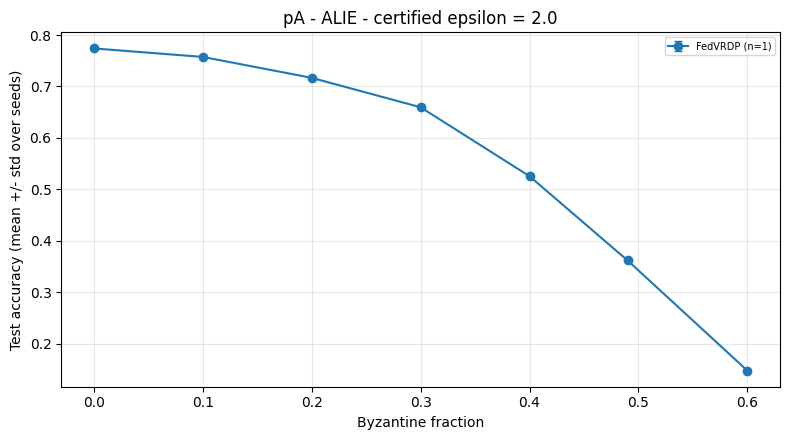

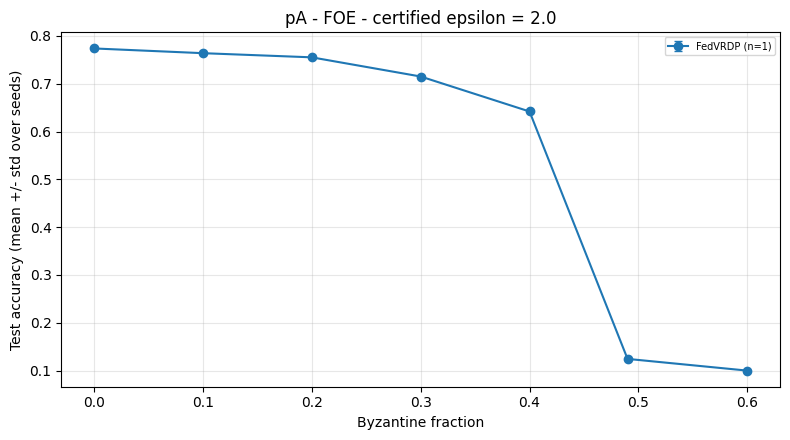

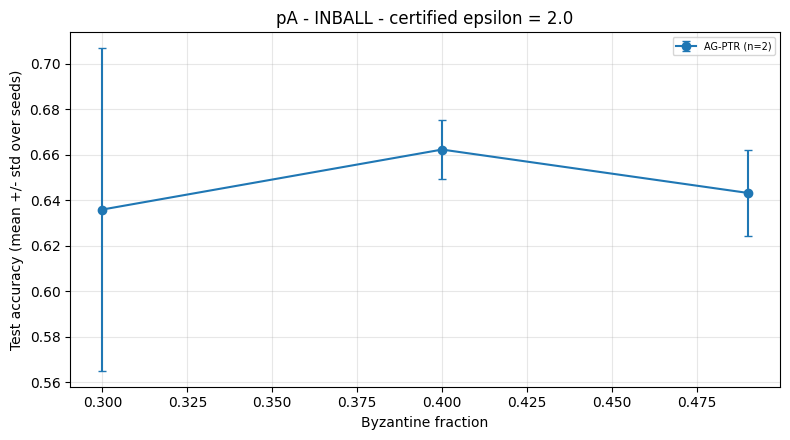

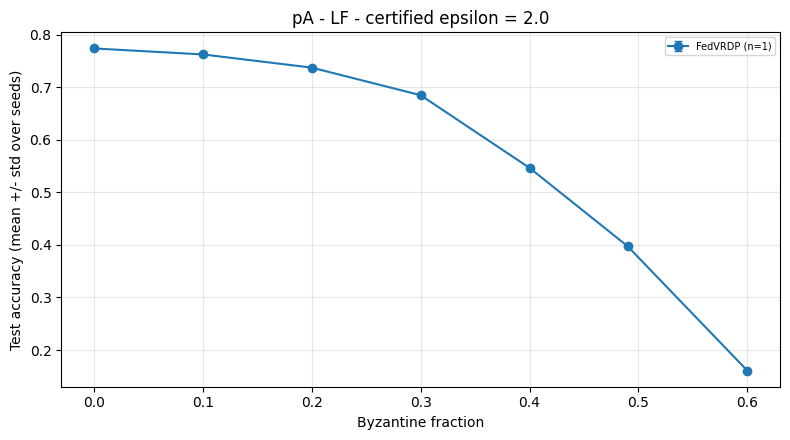

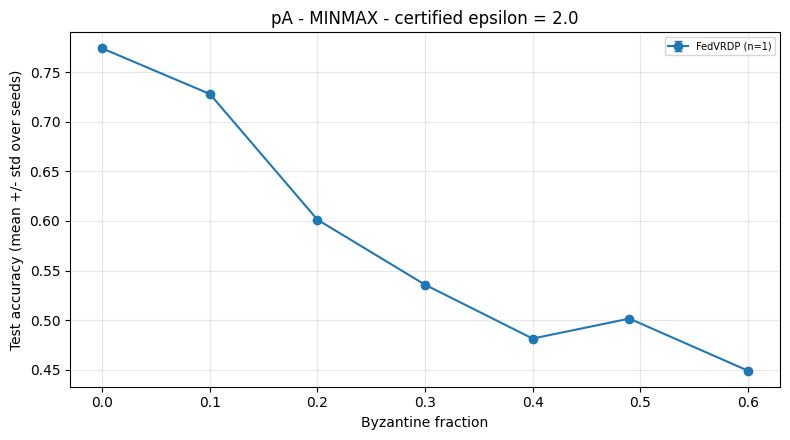

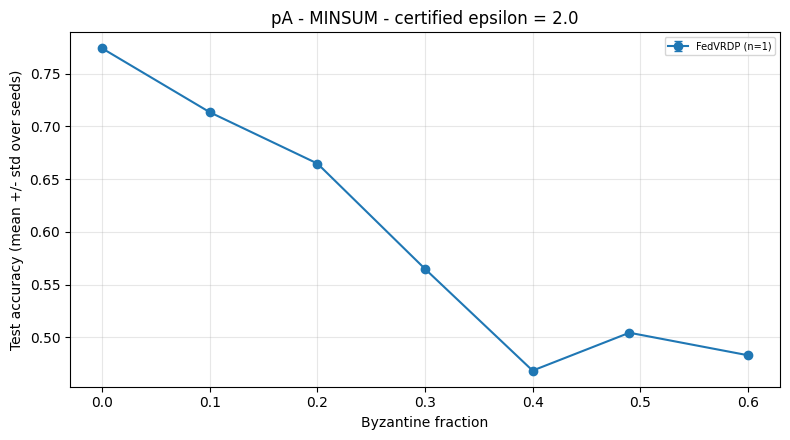

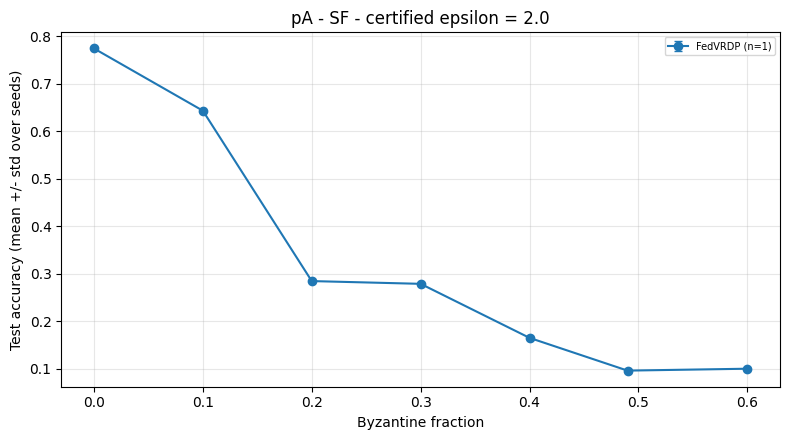

In [ ]:
# Cell 16i — JOB "fedvrdp": 42 runs: faithful FedVRDP under the common protocol (1 local epoch)

run_job("fedvrdp")
import_legacy("fedvrdp")
print_job_log("fedvrdp")
aggregate("fedvrdp")


JOB = fedvrdp10 | results file: /content/drive/MyDrive/agptr_runs/pA_results.csv
q = 0.016722 | sigma_dp = 0.9723 | AG-PTR: sigma_sel = 2.1742, sigma_rel = 1.0871 | certified epsilon = 2.000
48 runs already done, 42 to do
[1/42] seed=0 ALIE    f=0.00 FedVRDP-10ep             acc=0.8350 accept=1.000 (ok, 392s, ETA 268 min)
[2/42] seed=0 ALIE    f=0.10 FedVRDP-10ep             acc=0.8147 accept=1.000 (ok, 357s, ETA 250 min)
[3/42] seed=0 ALIE    f=0.20 FedVRDP-10ep             acc=0.7605 accept=1.000 (ok, 315s, ETA 231 min)
[4/42] seed=0 ALIE    f=0.30 FedVRDP-10ep             acc=0.6562 accept=1.000 (ok, 275s, ETA 212 min)
[5/42] seed=0 ALIE    f=0.40 FedVRDP-10ep             acc=0.4460 accept=1.000 (ok, 234s, ETA 194 min)
[6/42] seed=0 ALIE    f=0.49 FedVRDP-10ep             acc=0.2006 accept=1.000 (ok, 199s, ETA 177 min)
[7/42] seed=0 ALIE    f=0.60 FedVRDP-10ep             acc=0.1000 accept=1.000 (ok, 161s, ETA 161 min)
[8/42] seed=0 SF      f=0.00 FedVRDP-10ep             acc=0.8350

,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-10T06:26:47,0,ALIE,0.00,FedVRDP-10ep,0.8350,1.0,391.7,ok,NaN,2.0
1,2026-09-10T06:32:44,0,ALIE,0.10,FedVRDP-10ep,0.8147,1.0,356.8,ok,NaN,2.0
2,2026-09-10T06:37:59,0,ALIE,0.20,FedVRDP-10ep,0.7605,1.0,315.3,ok,NaN,2.0
3,2026-09-10T06:42:35,0,ALIE,0.30,FedVRDP-10ep,0.6562,1.0,275.4,ok,NaN,2.0
4,2026-09-10T06:46:29,0,ALIE,0.40,FedVRDP-10ep,0.4460,1.0,234.1,ok,NaN,2.0
5,2026-09-10T06:49:49,0,ALIE,0.49,FedVRDP-10ep,0.2006,1.0,199.4,ok,NaN,2.0
6,2026-09-10T06:52:30,0,ALIE,0.60,FedVRDP-10ep,0.1000,1.0,161.0,ok,NaN,2.0
7,2026-09-10T06:59:02,0,SF,0.00,FedVRDP-10ep,0.8350,1.0,392.0,ok,NaN,2.0
8,2026-09-10T07:05:01,0,SF,0.10,FedVRDP-10ep,0.7605,1.0,359.7,ok,NaN,2.0
9,2026-09-10T07:10:22,0,SF,0.20,FedVRDP-10ep,0.6083,1.0,320.7,ok,NaN,2.0


saved /content/drive/MyDrive/agptr_runs/pA_seed_summary.csv


,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,alie,ALIE,FedVRDP,0.00,0.7739,0.0,1,1.0,NaN
1,alie,ALIE,FedVRDP,0.10,0.7574,0.0,1,1.0,NaN
2,alie,ALIE,FedVRDP,0.20,0.7167,0.0,1,1.0,NaN
3,alie,ALIE,FedVRDP,0.30,0.6595,0.0,1,1.0,NaN
4,alie,ALIE,FedVRDP,0.40,0.5254,0.0,1,1.0,NaN
...,...,...,...,...,...,...,...,...,...
82,sf,SF,FedVRDP-10ep,0.20,0.6083,0.0,1,1.0,NaN
83,sf,SF,FedVRDP-10ep,0.30,0.5035,0.0,1,1.0,NaN
84,sf,SF,FedVRDP-10ep,0.40,0.3331,0.0,1,1.0,NaN
85,sf,SF,FedVRDP-10ep,0.49,0.1000,0.0,1,1.0,NaN


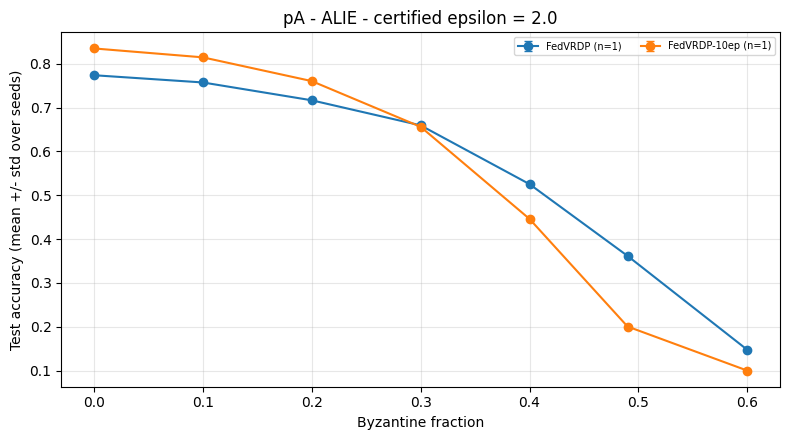

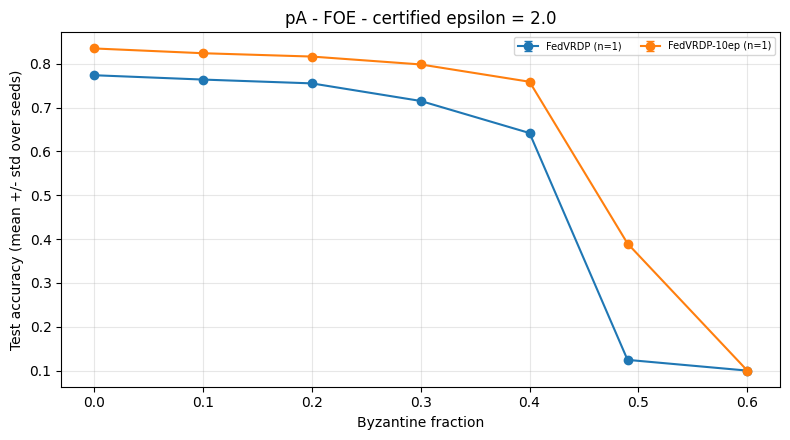

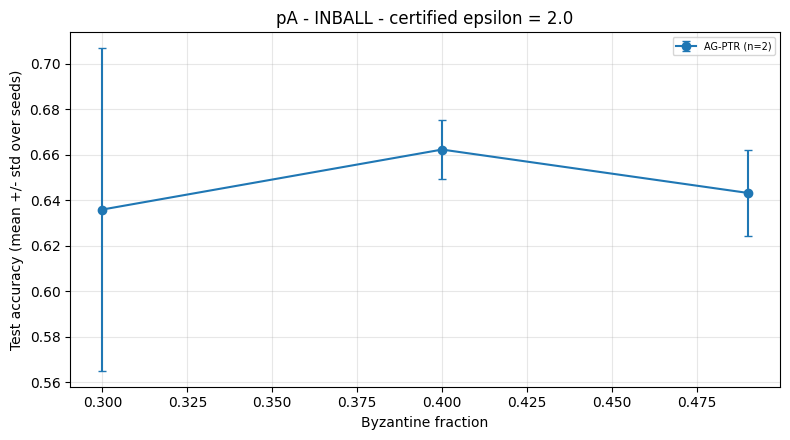

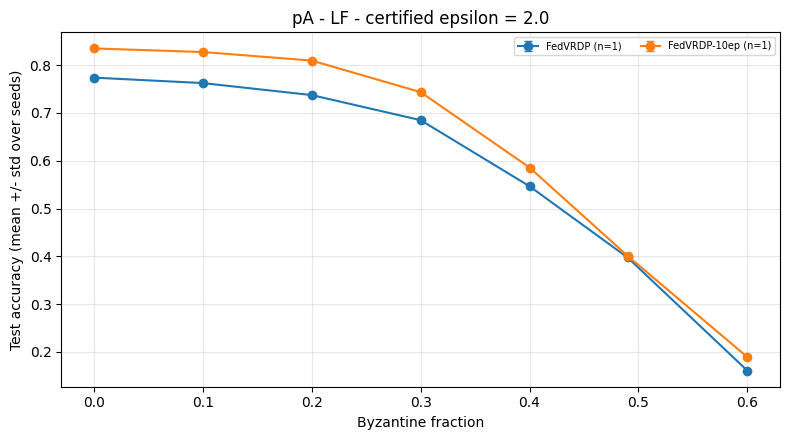

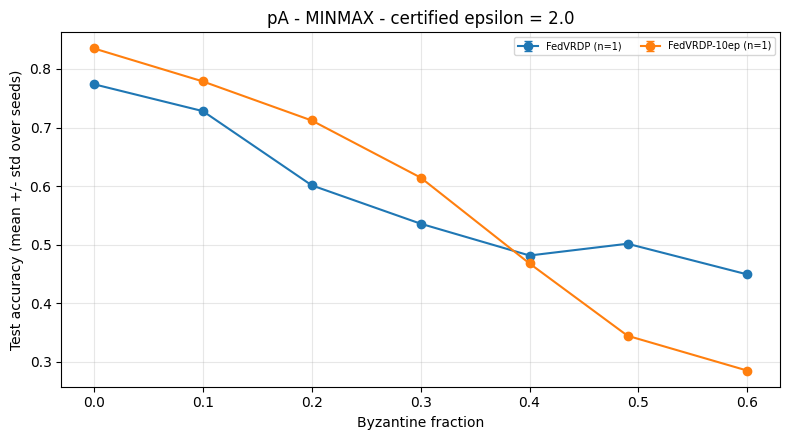

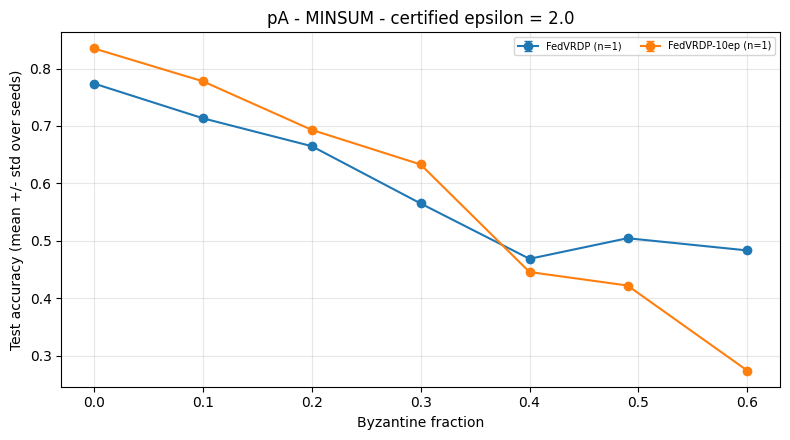

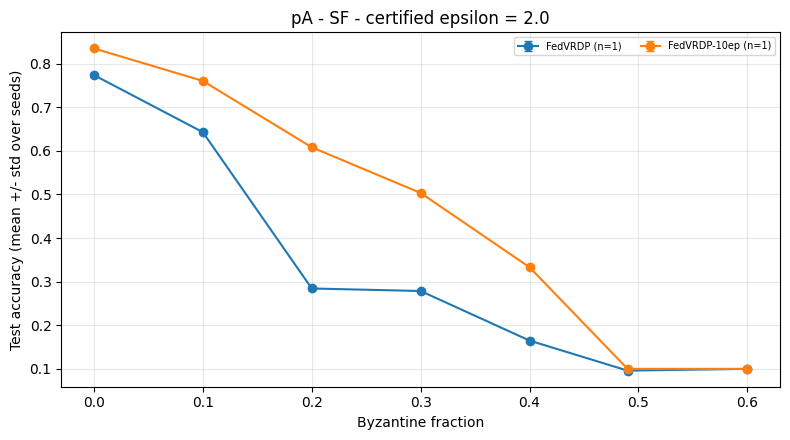

In [ ]:
# Cell 16j — JOB "fedvrdp10": 42 runs, ~3 h: faithful FedVRDP with the paper's 10 local epochs

run_job("fedvrdp10")
import_legacy("fedvrdp10")
print_job_log("fedvrdp10")
aggregate("fedvrdp10")


In [23]:
# Cell 16k — public-set-size ablation (AG-PTR only): 50 and 800 public samples, to compare with the 200 used everywhere else
# Rebuilds the public set and the IID client partition exactly as Cell 4 does (same seeds), with a different
# number of public samples per class, re-derives q and sigma_dp for the new number of clients, runs the job,
# and restores the default partition afterwards. 12 runs: Reference rows: the AG-PTR rows already in
# pA_results.csv (200 public samples, seed 0).
def set_public_size(per_class):
    global public_idx, clients, NUM_CLIENTS, q, sigma_dp
    public_idx = extract_public_per_class(train_ds, per_class=per_class, seed=0)
    _mask = np.ones(len(train_ds), dtype=bool); _mask[np.array(public_idx)] = False
    _avail = np.arange(len(train_ds))[_mask]
    NUM_CLIENTS = len(_avail) // SAMPLES_PER_CLIENT
    clients = build_iid_clients_from_indices(_avail[:NUM_CLIENTS * SAMPLES_PER_CLIENT], NUM_CLIENTS, SAMPLES_PER_CLIENT, seed=0)
    q = CLIENTS_PER_ROUND / len(clients)
    sigma_dp = find_sigma_for_target_eps_single(eps_total, q, 180, delta)
    print("public samples: %d | clients: %d | q = %.6f | sigma_dp = %.4f" % (len(public_idx), len(clients), q, sigma_dp))

for _per_class, _job in [(5, "pub50"), (80, "pub800")]:
    set_public_size(_per_class)
    run_job(_job)
    print_job_log(_job)
set_public_size(PUBLIC_PER_CLASS)   # restore the default (200 public samples) for any later job


public samples: 50 | clients: 5995 | q = 0.016681 | sigma_dp = 0.9716
JOB = pub50 | results file: /content/drive/MyDrive/agptr_runs/pA_results.csv
q = 0.016681 | sigma_dp = 0.9716 | AG-PTR: sigma_sel = 2.1725, sigma_rel = 1.0863 | certified epsilon = 2.000
0 runs already done, 6 to do
[1/6] seed=0 ALIE    f=0.00 AG-PTR (pub=50)          acc=0.7513 accept=0.894 (ok, 102s, ETA 8 min)
[2/6] seed=0 ALIE    f=0.30 AG-PTR (pub=50)          acc=0.7588 accept=0.467 (ok, 76s, ETA 6 min)
[3/6] seed=0 ALIE    f=0.40 AG-PTR (pub=50)          acc=0.7018 accept=0.294 (ok, 71s, ETA 4 min)
[4/6] seed=0 MinMax  f=0.00 AG-PTR (pub=50)          acc=0.7513 accept=0.894 (ok, 98s, ETA 3 min)
[5/6] seed=0 MinMax  f=0.30 AG-PTR (pub=50)          acc=0.7469 accept=0.661 (ok, 83s, ETA 1 min)
[6/6] seed=0 MinMax  f=0.40 AG-PTR (pub=50)          acc=0.7458 accept=0.367 (ok, 74s, ETA 0 min)
done for now: /content/drive/MyDrive/agptr_runs/pA_results.csv
FULL LOG for job 'pub50': 6 completed runs over all sessions (

,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-10T18:53:29,0,ALIE,0.0,AG-PTR (pub=50),0.7513,0.894444,101.5,ok,1.086259,2.0
1,2026-09-10T18:54:45,0,ALIE,0.3,AG-PTR (pub=50),0.7588,0.466667,75.9,ok,1.086259,2.0
2,2026-09-10T18:55:56,0,ALIE,0.4,AG-PTR (pub=50),0.7018,0.294444,71.3,ok,1.086259,2.0
3,2026-09-10T18:57:34,0,MinMax,0.0,AG-PTR (pub=50),0.7513,0.894444,97.8,ok,1.086259,2.0
4,2026-09-10T18:58:57,0,MinMax,0.3,AG-PTR (pub=50),0.7469,0.661111,83.1,ok,1.086259,2.0
5,2026-09-10T19:00:12,0,MinMax,0.4,AG-PTR (pub=50),0.7458,0.366667,74.4,ok,1.086259,2.0


public samples: 800 | clients: 5920 | q = 0.016892 | sigma_dp = 0.9753
JOB = pub800 | results file: /content/drive/MyDrive/agptr_runs/pA_results.csv
q = 0.016892 | sigma_dp = 0.9753 | AG-PTR: sigma_sel = 2.1809, sigma_rel = 1.0905 | certified epsilon = 2.000
6 runs already done, 6 to do
[1/6] seed=0 ALIE    f=0.00 AG-PTR (pub=800)         acc=0.7686 accept=0.972 (ok, 98s, ETA 8 min)
[2/6] seed=0 ALIE    f=0.30 AG-PTR (pub=800)         acc=0.7549 accept=0.783 (ok, 79s, ETA 6 min)
[3/6] seed=0 ALIE    f=0.40 AG-PTR (pub=800)         acc=0.7099 accept=0.400 (ok, 71s, ETA 4 min)
[4/6] seed=0 MinMax  f=0.00 AG-PTR (pub=800)         acc=0.7686 accept=0.972 (ok, 98s, ETA 3 min)
[5/6] seed=0 MinMax  f=0.30 AG-PTR (pub=800)         acc=0.7389 accept=0.806 (ok, 84s, ETA 1 min)
[6/6] seed=0 MinMax  f=0.40 AG-PTR (pub=800)         acc=0.7339 accept=0.417 (ok, 76s, ETA 0 min)
done for now: /content/drive/MyDrive/agptr_runs/pA_results.csv
FULL LOG for job 'pub800': 6 completed runs over all sessions

,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-10T19:01:56,0,ALIE,0.0,AG-PTR (pub=800),0.7686,0.972222,98.1,ok,1.090474,2.0
1,2026-09-10T19:03:15,0,ALIE,0.3,AG-PTR (pub=800),0.7549,0.783333,79.4,ok,1.090474,2.0
2,2026-09-10T19:04:26,0,ALIE,0.4,AG-PTR (pub=800),0.7099,0.400000,71.0,ok,1.090474,2.0
3,2026-09-10T19:06:04,0,MinMax,0.0,AG-PTR (pub=800),0.7686,0.972222,97.6,ok,1.090474,2.0
4,2026-09-10T19:07:28,0,MinMax,0.3,AG-PTR (pub=800),0.7389,0.805556,84.0,ok,1.090474,2.0
5,2026-09-10T19:08:44,0,MinMax,0.4,AG-PTR (pub=800),0.7339,0.416667,75.8,ok,1.090474,2.0


public samples: 200 | clients: 5980 | q = 0.016722 | sigma_dp = 0.9723
